# Machine Learning
## Project 3
### Adam John Holt

## Outline

The purpose of this notebook is to investigate a range of machine learning techniques with a focus on *unsupervised* methods. Specifically, we shall utilise dimension reduction techniques (i.e., Principal Component Analysis - PCA); data clustering methods such as k-means and agglomerative hierarchical; and a number of *supervised* methods for the purpose of classification. The first part of our investigation will focus on modelling of breast cancer diagnosis. In the second part, we look into the safety records of international airlines over distinct time periods and attempt to characterise the safety records with similar features. Finally, in the third part of this notebook, we investigate crime rate statistics by grouping criminal arrest types in various states of the USA. 

### Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import warnings
import os

# Suppress redundant warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

## A Model for Diagnosing Cancer

Determining whether a tumour is __malignant__ or __benign__ is one of the challenging aspects when treating cancer. Machine learning techniques can help identify cancer types by extracting the differences in cell nucleus features. Here we will employ a range of supervised and unsupervised techniques on the [Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)) (diagnostic) dataset in order to explore the data features and to classify the diagnostic status of the cancer tumor. The ["Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image." ](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)) Specifically, the data is composed of features:

* __Patient ID__ number
* __Diagnosis__ (M = malignant, B = benign) 
* Ten cell nucleus features, namely:
    - __radius__ (mean of distances from centre to points on the perimeter)
    - __texture__ (standard deviation of grayscale values)
    - __perimeter__
    - __area__
    - __smoothness__ (local variation in radius lengths)
    - __compactness__ ($perimeter^2 / area - 1.0$)
    - __concavity__ (severity of concave portions of the contour)
    - __concave points__ (number of concave portions of the contour) • symmetry
    - __fractal dimension__ (‘coastline approximation’ - 1)

Such FNA samples typically appear as in the image below.

![breast cancer image](https://www.frontiersin.org/files/Articles/572671/fdgth-02-572671-HTML/image_m/fdgth-02-572671-g001.jpg)

### Task 1.

To begin the investigation we shall build and compare logistic regression and decision tree models to predict the tumour status. Specifically, we will perform grid search cross-validation in order to determine optimal hyperparameter values after which we can analyse the various performance metrics and classification results. Firstly, we must perform the appropriate data preprocessing.

In [2]:
# Load & inspect data structure
cancer = pd.read_csv('breast-cancer.csv')
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


In [3]:
# id extraneous - remove
cancer.drop('id', axis=1, inplace=True)
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), object(1)
memory usage: 49.0+ KB


We see that the data is composed of 568 observations on the 10 numeric features described earlier in addition to the diagnostic outcome (i.e., `M`alignant or `B`enign). The data is free of missing values and we can therefore initiate some basic exploration. To begin we inspect the distributional characteristics of the features (i.e., mean and standard deviation).

In [4]:
# Feature means, standard deviations
mean_std = cancer.drop(
    'diagnosis', axis=1
    ).describe().loc[['mean', 'std'], :].transpose().sort_values(
        by='mean', ascending=False
    )

mean_std

,mean,std
area_mean,654.889104,351.914129
perimeter_mean,91.969033,24.298981
texture_mean,19.289649,4.301036
radius_mean,14.127292,3.524049
symmetry_mean,0.181162,0.027414
compactness_mean,0.104341,0.052813
smoothness_mean,0.096360,0.014064
concavity_mean,0.088799,0.079720
fractal_dimension_mean,0.062798,0.007060
concave points_mean,0.048919,0.038803


The table of means and standard deviations indicate that the feature distributions vary significantly with respect to scale (multiple orders of magnitude) and will therefore need to be standardized as part of preprocessing. Furthermore, we are aware that the presence of outliers has the potential to negatively affect the accuracy of regression models (i.e., the logistic regression model we aim to implement) applied on the data. Hence we must determine if outliers are present in the data and necessarily remove them if so. Boxplots are appropriate for this task.

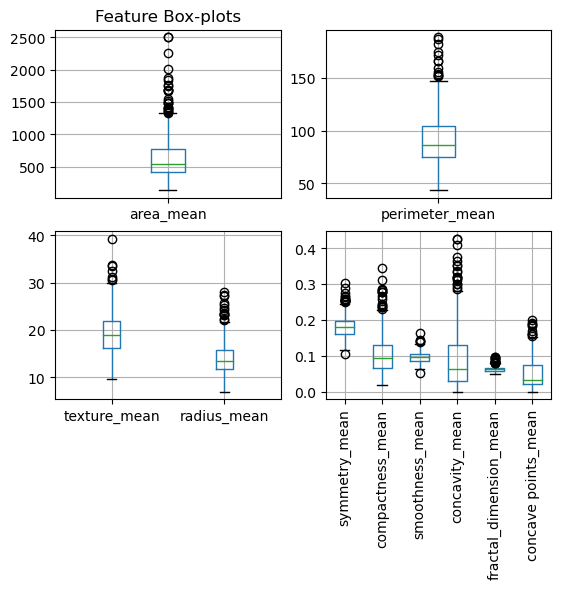

In [5]:
# Feature box-plots (differing scales)
plt.subplot(2,2,1)
cancer[['area_mean']].boxplot()
plt.title('Feature Box-plots')
plt.subplot(2,2,2)
cancer[['perimeter_mean']].boxplot()
plt.subplot(2,2,3)
cancer[['texture_mean', 'radius_mean']].boxplot()
plt.subplot(2,2,4)
cancer[mean_std.index[4:]].boxplot()
plt.xticks(rotation=90);

Inspecting the box-plots above we can see that outliers are present in the data and we will therefore need to return to this matter in the final data preparation phase where we will remove such outliers in conjuction to performing scale transformations and splitting the data into training and test sets. Let us now investigate feature correlations, i.e., we plot a heatmap of these correlations and collect the absolute correlations into a table ordered from greatest to least.

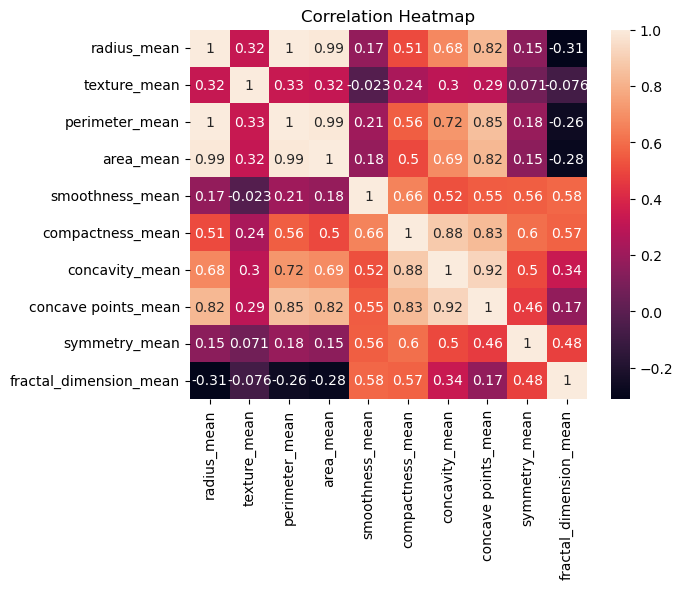

In [6]:
# Feature correlations
sns.heatmap(cancer.loc[:, cancer.columns != 'diagnosis'].corr(), annot=True)
plt.title('Correlation Heatmap');

In [7]:
# Absolute correlations - greatest to least
df_corr = cancer.loc[:, cancer.columns != 'diagnosis'].corr().abs()
corrs = df_corr.stack().sort_values(ascending=False).drop_duplicates()[1:,]
corrs = corrs.rename_axis(('Feature 1', 'Feature 2')).reset_index(name='Abs. Correlation')
corrs.head(20)

,Feature 1,Feature 2,Abs. Correlation
0,radius_mean,perimeter_mean,0.997855
1,area_mean,radius_mean,0.987357
2,area_mean,perimeter_mean,0.986507
3,concave points_mean,concavity_mean,0.921391
4,concavity_mean,compactness_mean,0.883121
5,perimeter_mean,concave points_mean,0.850977
6,compactness_mean,concave points_mean,0.831135
7,area_mean,concave points_mean,0.823269
8,concave points_mean,radius_mean,0.822529
9,perimeter_mean,concavity_mean,0.716136


Recalling that the the features in our data are measures of the geometric characteristics of cancer cell biopsies, it is clear that the shape of the cell nuclei is of significant importance in diagnosis, and that the geometric characteristics of these cell nuclie such as area and radius will be correlated (see table above). It is also clear then that certain functional dependencies will be present between these features. These dependencies are illustrated by the almost perfect linear correlation between geometric characteristics exhibited in the `radius_mean`, `perimeter_mean` and the also highly correlated features `area_mean`, `radius_mean` (see plots below).

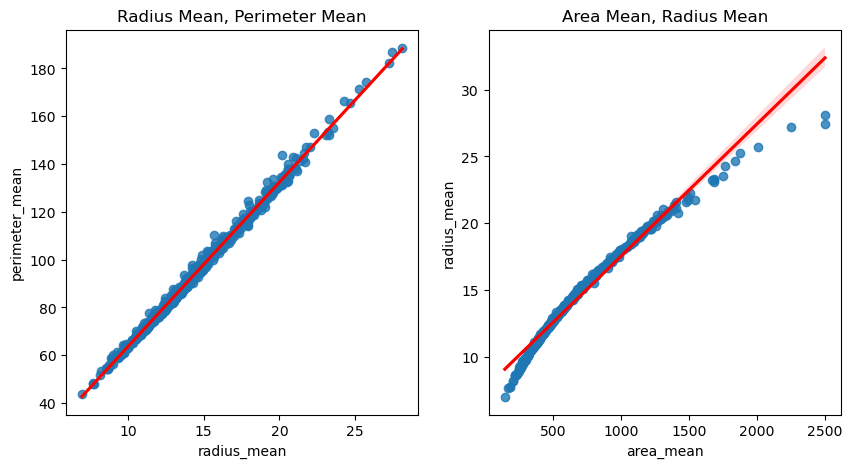

In [8]:
# Highly linearly correlated features
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.regplot(
    cancer, x=corrs['Feature 1'][0], 
    y=corrs['Feature 2'][0], 
    line_kws={"color": "red"}
).set(title='Radius Mean, Perimeter Mean');
plt.subplot(1,2,2)
sns.regplot(
    cancer, x=corrs['Feature 1'][1], 
    y=corrs['Feature 2'][1], 
    line_kws={"color": "red"}
).set(title='Area Mean, Radius Mean');

From the above table and plots we can see that multicollinearity is present in the data. In particular, we can see from the linear regression fits in the scatterplots above that the mean radius and perimeter are linear throughout the range but that the linear relationship between mean area and radius breaks down at the extremes of the distribution. It is therefore suitable to remove some features that exhibit the strongest linear relationship (i.e., it will be sufficient to keep only one of these features). To determine which features to remove we will filter out one of the features from the pairs where the absolute correlation is greater than or equal to 0.95.

In [9]:
# Greatest absolute correlated features (non-duplicate)
tri_corr_mtx = df_corr.mask(np.triu(np.ones_like(df_corr, dtype=bool)))
high_corrs = [c for c in tri_corr_mtx.columns if any(tri_corr_mtx[c] >= 0.95)]
high_corrs

['radius_mean', 'perimeter_mean']

In [10]:
# Remove radius_mean, perimeter_mean
cancer.drop(high_corrs, axis=1, inplace=True)

Now that we have removed a single feature from those pairs with correlation greater than 0.95 we can inspect the distrubtions of the remaining features (scatterplots shown below) where we see that some feature pairs present well separated clusters for the diagnosis (e.g., `texture_mean`, `area_mean`) and that the desity estimates of the diagnoses differ in their means and the variance.  

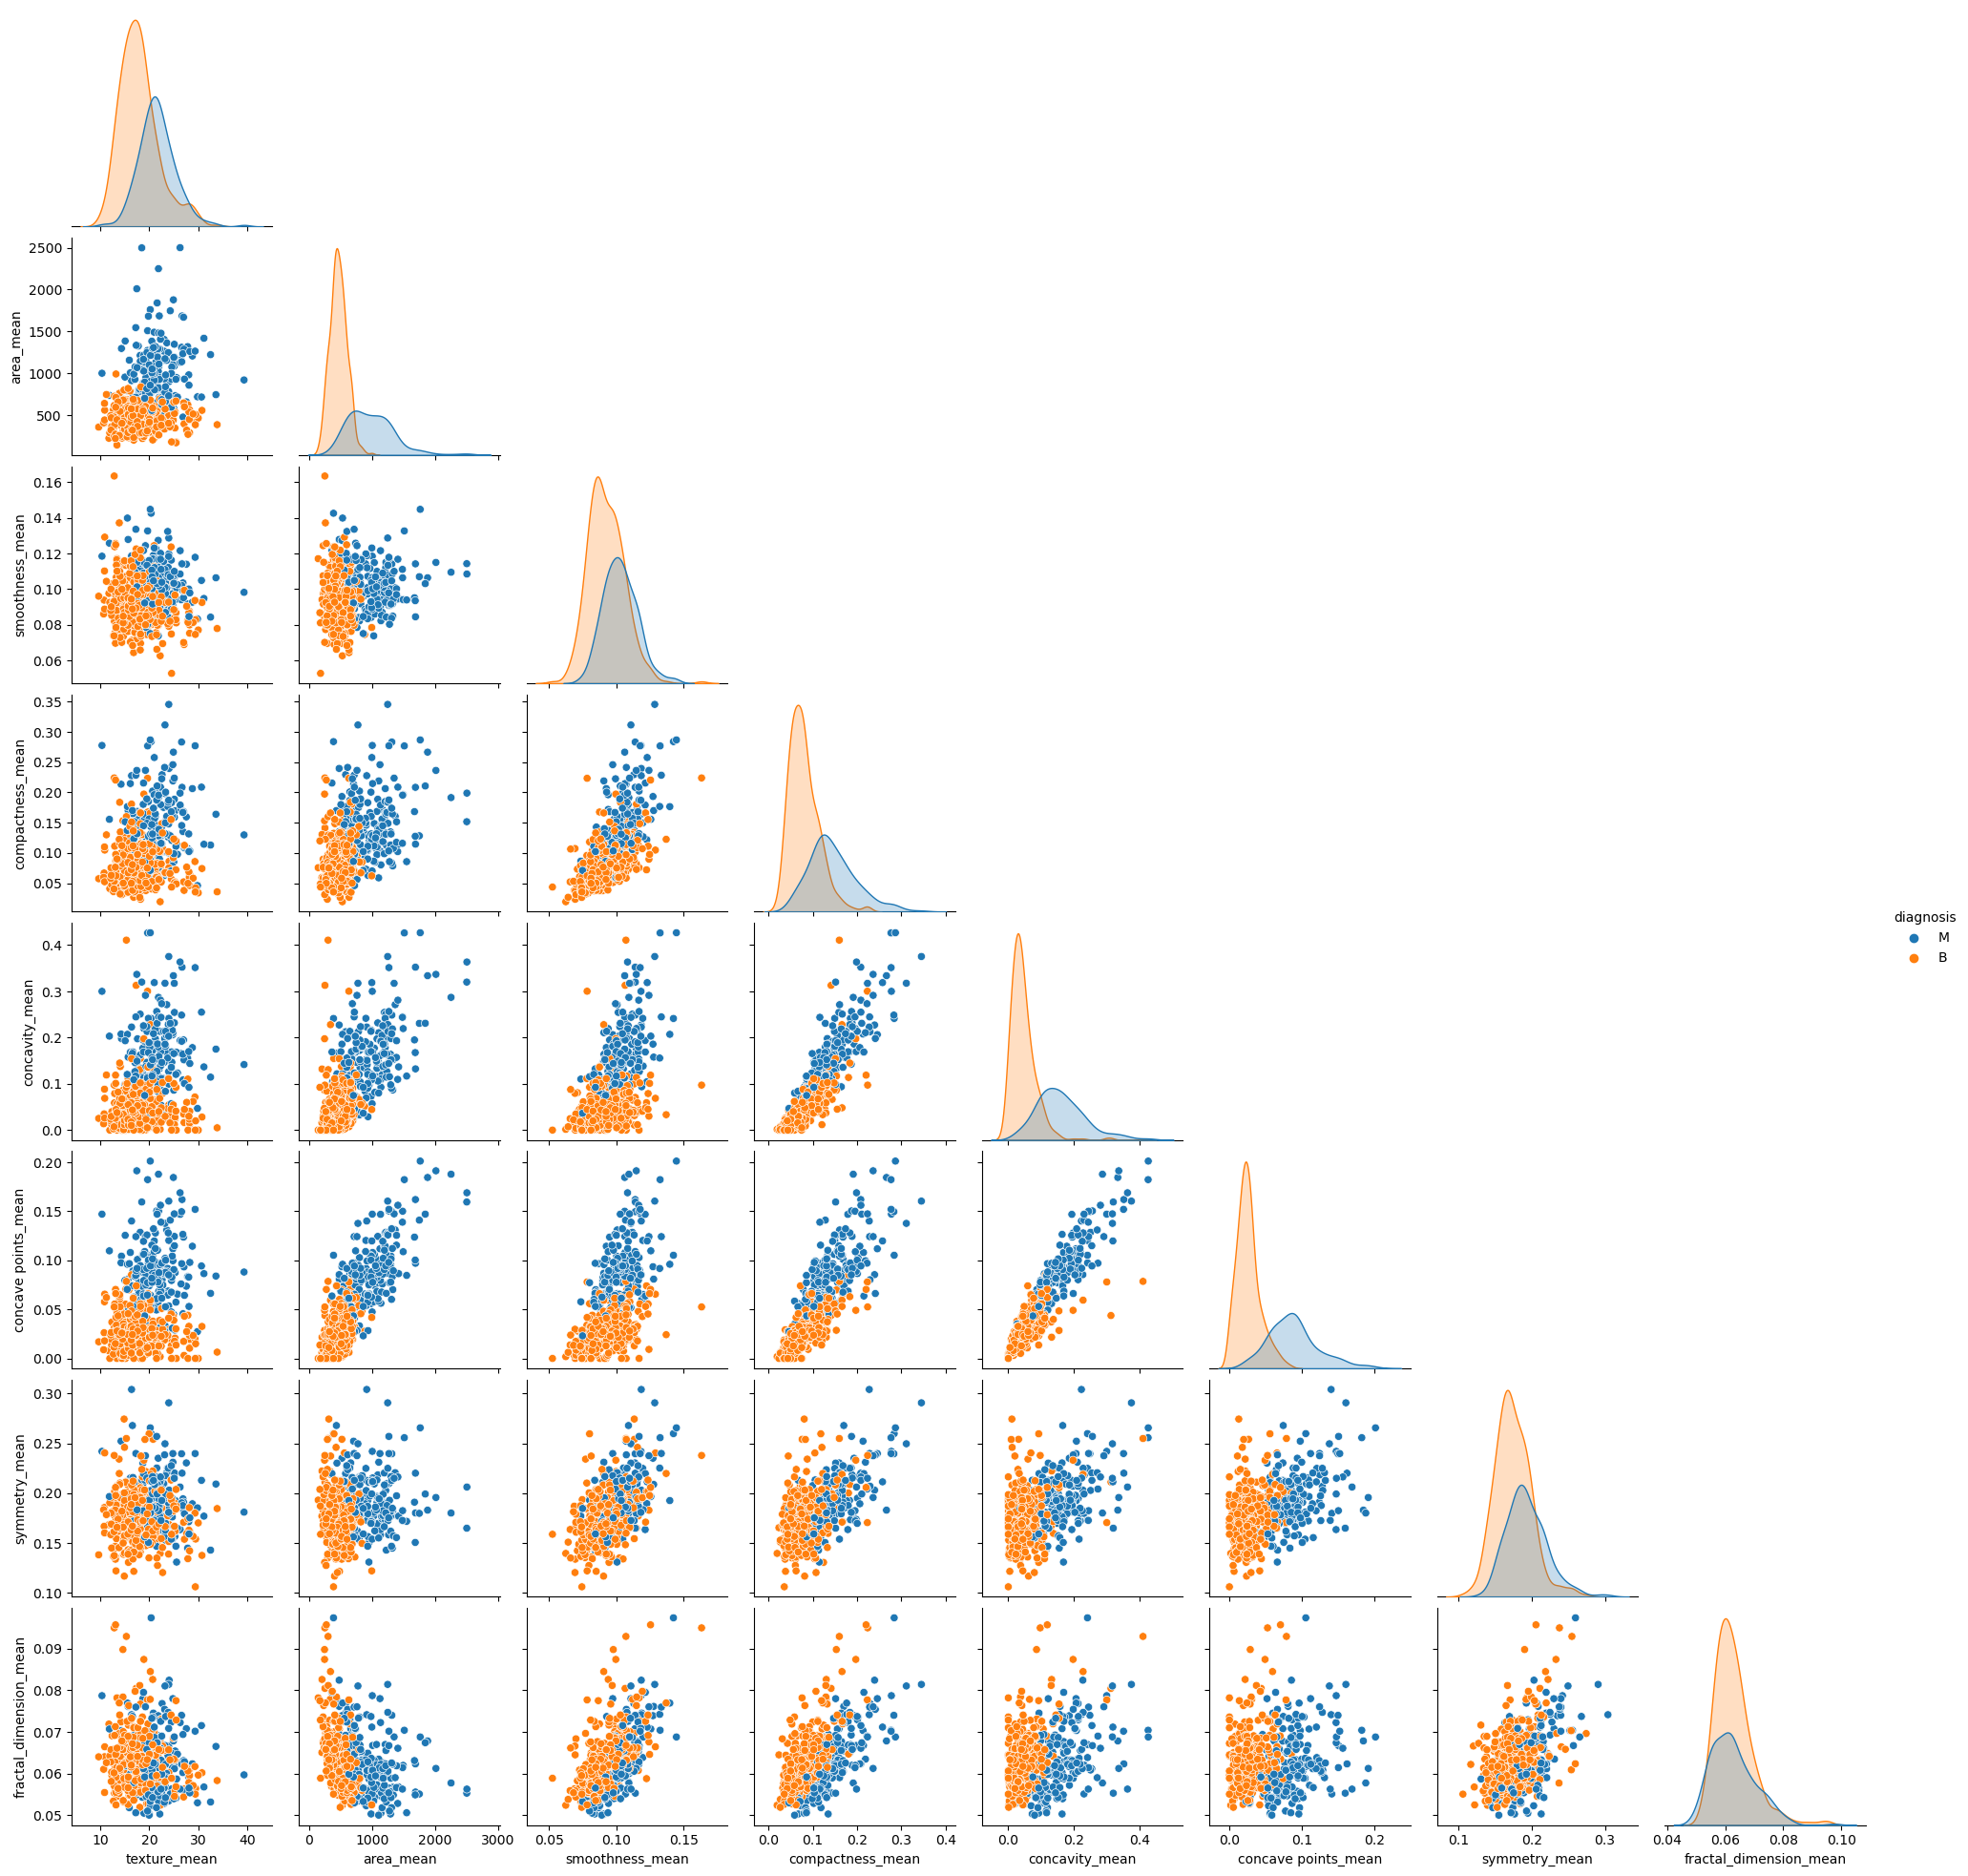

In [11]:
sns.pairplot(cancer, hue='diagnosis', corner=True);

Before splitting the data into training and test sets we must determine if there is an imbalance present in the target feature (i.e., diagnosis __Benign__ or __Malignant__). In the pie chart below we see that the target feature is indeed imbalanced with approx. 63% of samples __Benign__ and 37% of samples __Malignant__, hence we will need to stratify the the data split into training and test on the target in order to maintain a balanced sampling.

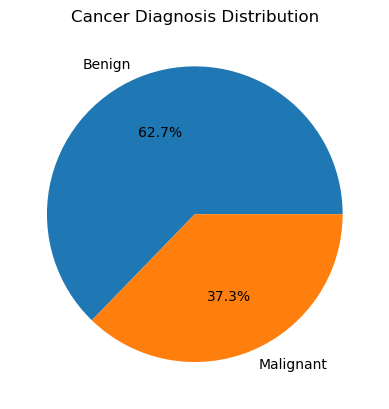

In [12]:
# Target distribution - pie chart
counts = cancer.diagnosis.value_counts()
counts = counts / counts.sum()
plt.pie(counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%')
plt.title('Cancer Diagnosis Distribution');

To conclude our data exploration and preparation we finalise the preprocessing phase by first ecoding the target feature, then we implement the functionality required for removing outliers in addition to performing scale transformations (i.e., standardization) and partitioning the data into training and test sets.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode target feature lable
cancer.diagnosis = pd.Series([1 if d == 'M' else 0 for d in cancer.diagnosis])

# Remove outliers - samples outside 1.5 * interquartile range (IQR)
def remove_outliers(data):
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1 
        filter = (
            data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 *IQR
            )
        data = data.loc[filter]  
    return data


# Scale & test/train split
def prepare_data(data, target, test_prop):
    data = remove_outliers(data)
    X = data.drop(target, axis=1)
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_prop, stratify=y, random_state=42
    )
    std_scaler = StandardScaler().fit(X_train)
    X_train_std = std_scaler.transform(X_train)
    X_test_std = std_scaler.transform(X_test)
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    return X_train_std, X_test_std, y_train, y_test


In [14]:
X_train, X_test, y_train, y_test = prepare_data(
    data=cancer, target='diagnosis', test_prop=0.20
)

The data are now ready to be employed in model training. As outlined above, for the cancer classification task we shall implement two models:
- Logistic Regression Classifier
- Decision Tree Classifier

In particular, we will determine the optimal model specification for these classifiers by tuning the appropriate hyperparameters via grid search and cross validation (i.e., `GridSearchCV-LogisticRegression`, `GridSearchCV-DecisionTree`).

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(random_state=42)
dtree = DecisionTreeClassifier(random_state=42)

# Logistic regression hyperparameter grid
logreg_params = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear'],
    'penalty': ['none', 'l1', 'l2', 'elasticnet'],
    'C': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100],
}

# Decision tree hyperparameter grid
dtree_params = {
    'splitter': ['best', 'random'],
    'max_depth': [2,3,4,5,6,7,8,9,10,20,30,40,50],
    'min_samples_leaf': [2,3,4,5,6,7,8,9,10,20,30,40,50],
}

logreg_cv = GridSearchCV(logreg, logreg_params, scoring='accuracy', cv=5)
dtree_cv = GridSearchCV(dtree, dtree_params, scoring='accuracy', cv=5)

The hyperparameter grids (above) utilize a combination of parameters to tune the respective classifier models with 5 fold cross validation. For the `GridSearchCV-LogisticRegression` model we have chosen to tune the following parameters:
- `solver` specifies the algorithm to use in the optimization problem.
- `penalty` specifies the norm of the penalty, i.e., regularization.
- `C` specifies the degree of model regularization, i.e., it represents the trade off between misclassification of training examples against the simplicity of the decision surface. Decreasing `C` corresponds to more regularization.

For the `GridSearchCV-DecisionTree` model we have chosen to tune the following parameters:
- `splitter` specifies the strategy used to choose the split at each node. Supported strategies are __best__ to choose the best split and __random__ to choose the best random split.
- `max_depth` specifies the maximum depth of the tree. 
- `min_samples_leaf` specifies the minimum number of samples required to be at a leaf node. 

With the hyperparameter grids specified we can fit the models and inspect the results.

In [16]:
# Fit models
logreg_cv.fit(X_train, y_train);
dtree_cv.fit(X_train, y_train);

In [17]:
# Best parameterization & score - logistic regression
print('Logistic Regression Hyperparameters:', logreg_cv.best_params_)
print('Logistic Regression Accuracy:', logreg_cv.best_score_)

# Best parameterization & score - decision tree
print('Decision Tree Hyperparameters:', dtree_cv.best_params_)
print('Decision Tree Accuracy:', dtree_cv.best_score_)

Logistic Regression Hyperparameters: {'C': 1e-05, 'penalty': 'none', 'solver': 'newton-cg'}
Logistic Regression Accuracy: 0.92987012987013
Decision Tree Hyperparameters: {'max_depth': 9, 'min_samples_leaf': 3, 'splitter': 'random'}
Decision Tree Accuracy: 0.9324675324675324


We see that the grid search has identified the optimal hyperparameter values for the logistic regression and decision tree models respectively, namely:
- __C__: $10^{-5}$; __penalty__: none; __solver__: newton-cg
- __max_depth__: 9; __min_samples_leaf__: 3; __splitter__: random

Additionally, we see that the models have comparable average accuracy across the 5 folds of the training data cross validation, i.e., both approx. 0.93. In order to determine the generalization capacity of the respective models we must emply them on the test data. In the following we extract the model predictions on the test data and collect and display various classification performance metrics, i.e., _accuracy_; _precision_; _recall_; _f1_; and area under the reciever operating characteristic curve (_roc auc_).

In [18]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

classifiers = [logreg_cv, dtree_cv]
classifier_names = ['GridSearchCV-LogisticRegression', 'GridSearchCV-DecisionTree']

# Collect performance metrics - test set
results = {
    'accuracy': [
        accuracy_score(y_test, classifier.predict(X_test)) for classifier in classifiers
        ],
    'precision': [
        precision_score(y_test, classifier.predict(X_test)) for classifier in classifiers
        ],
    'recall': [
        recall_score(y_test, classifier.predict(X_test)) for classifier in classifiers
        ],
    'f1': [
        f1_score(y_test, classifier.predict(X_test)) for classifier in classifiers
        ],
    'roc auc': [
        roc_auc_score(y_test, classifier.predict(X_test)) for classifier in classifiers
        ],
}

# Display results
results_df = pd.DataFrame(results, index=classifier_names).rename_axis('Classifier')
results_df

,accuracy,precision,recall,f1,roc auc
Classifier,,,,,
GridSearchCV-LogisticRegression,0.948454,0.931034,0.9,0.915254,0.935075
GridSearchCV-DecisionTree,0.917526,0.923077,0.8,0.857143,0.885075


Inspecting the above table, it is quite clear that the logistic regression model (`GridSearchCV-LogisticRegression`) generalizes better to the test data than does the decision tree model (`GridSearchCV-DecisionTree`) as the performance across all metrics is superior. Importantly, if we consider the _roc auc_, which provides an aggregate measure of performance across all possible classification thresholds, we can see that the logistic regression model outperforms the decision tree by a wide margin (i.e., approx. 0.935 vs. 0.885 respectively). In order to better understand the difference in classification performance between the models we can investigate the particular classification errors by displaying the confusion matrices.

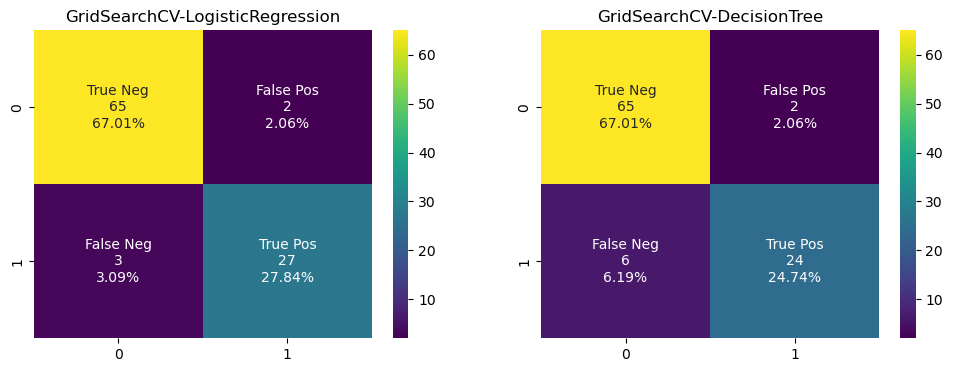

In [19]:
from sklearn.metrics import confusion_matrix

# Format & display confusion matrix 
def display_conf_mtx(conf_mtx, title):
    cells = [
        f"{label_1}\n{label_2}\n{label_3}" for label_1, label_2, label_3 in zip(
            ['True Neg','False Pos','False Neg','True Pos'],
            ["{0:0.0f}".format(value) for value in conf_mtx.flatten()],
            ["{0:.2%}".format(value) for value in conf_mtx.flatten()/np.sum(conf_mtx)]
        )
    ]
    cells = np.asarray(cells).reshape(2,2)
    sns.heatmap(conf_mtx, annot=cells, fmt='', cmap='viridis').set(title=title)


# Plot confusion matrices - logistic regression, decision tree - test set
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
conf_mtx_1 = confusion_matrix(y_test, logreg_cv.predict(X_test), labels=logreg_cv.classes_)
display_conf_mtx(conf_mtx_1, title=classifier_names[0])
plt.subplot(1,2,2)
conf_mtx_2 = confusion_matrix(y_test, dtree_cv.predict(X_test), labels=dtree_cv.classes_)
display_conf_mtx(conf_mtx_2, title=classifier_names[1]);

By analyzing the above confusion matrices we can see that the distribution of correct classifications (i.e., __True Negative__ and __True Positive__) is similar for the respective classifiers but the decision tree model has a slightly lower __True Positive__ ratio of approx. 25% than the logistic regression model of approx. 29%. Importantly, this comes at the additional expense of a much higher __False Negative__ ratio of approx. 6% for the decision tree over the logistic regression model which is approx. 3%. An important consideration is necessary regarding these data - the objective of the classifier is to use the data to determine the malignancy of a breast cancer sample. In such cases as this, there is much greater importance on preventing __False Negative__ diagnosis than in correctly identifying a __True Positive__ diagnosis and also in making a __False Positive__ error. For this reason, the __False Negative Rate__ is critically important in the determination of the optimal classifier. Ideally, the __False Negative Rate__ should be as small as possible. From the results (below) we can see that the __False Negative Rate__ of the decision tree classifier is double that of the logistic regression classifier (i.e., 0.2 vs. 0.1 respectively). Considering this in the context of the malignancy of a breast cancer biopsy, it is clear that the logistic regression model is superior to the decision tree model with respect to the data under investigation.

In [20]:
# False Negative Rates
TN, FP, FN, TP = confusion_matrix(y_test, logreg_cv.predict(X_test)).ravel()
FNR_1 = FN/(TP+FN)
TN, FP, FN, TP = confusion_matrix(y_test, dtree_cv.predict(X_test)).ravel()
FNR_2 = FN/(TP+FN)

print(classifier_names[0], 'False Negative Rate:', FNR_1)
print(classifier_names[1], 'False Negative Rate:', FNR_2)

GridSearchCV-LogisticRegression False Negative Rate: 0.1
GridSearchCV-DecisionTree False Negative Rate: 0.2


### Task 2.

To determine the relative importance of features in model predictions we can inspect the coefficient values and the mean decrease in impurity for the logistic regression and decision tree models respectively. Inspecting the plot below we can see that the area, concavity and compactness (i.e., `area_mean`, `concavity_mean`, `compactness_mean`) have the largest magnitude coefficients (i.e., importance) in the logsitic regression model. Similarly, concavity and area (i.e., `concave_points_mean`, `concavity_mean`, `area_mean`) are highly important in the decision tree model.

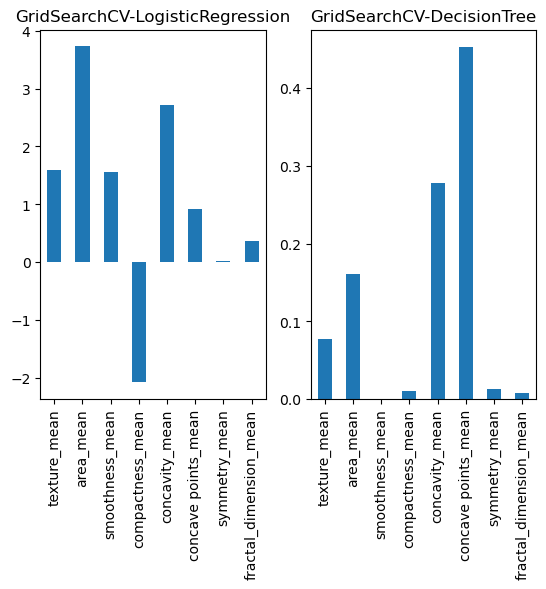

In [21]:
# Plot unscaled feature importances
plt.subplot(1,2,1)
pd.Series(
    logreg_cv.best_estimator_.coef_[0],
    cancer.columns[1:],
).plot(kind='bar')
plt.title(classifier_names[0])
plt.subplot(1,2,2)
pd.Series(
    dtree_cv.best_estimator_.feature_importances_,
    cancer.columns[1:],
).plot(kind='bar')
plt.title(classifier_names[1])
plt.show()

Due to the differing metrics of importance for the logistic regression and decision tree models it will be helpful for comparison to place the importances on the same scale. Specifically, in the plot below we see that the standardised feature importances for logistic regression idenfify `area_mean` as most important, whilst the decision tree model recognizes `concave_mean_points` equally important. Additionally, `fractal_dimension_mean` and `symmetry_mean` are relatively unimportant for both models. Furthermore, it appears that a large difference in the models is with respect to the importance of `compactness_mean` and `smoothness_mean`, i.e., these measures are unimportant for the decision tree but are important for the logistic regression model. Finally, the conclusion appears to be that __area__ and __concavity__ are very important characteristics for tumor classification, i.e., the size of the tumor and it's irregularity of it's border.

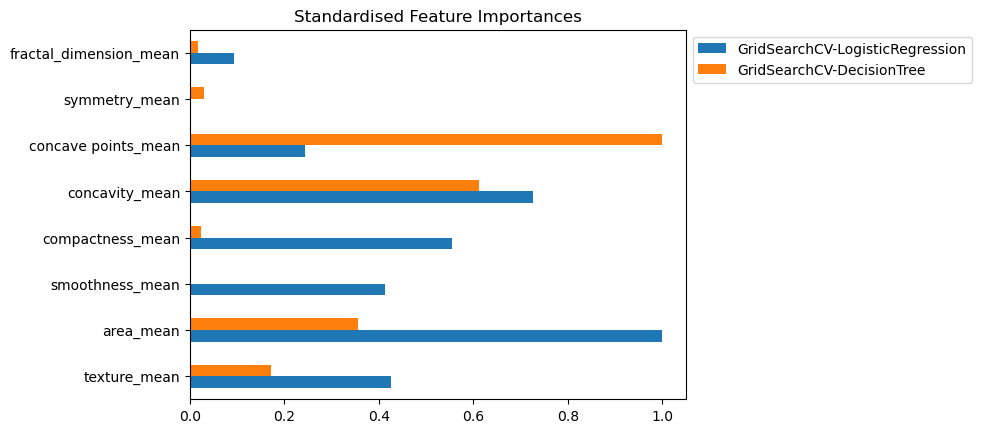

In [22]:
# Standardised logistic regression importances
lr_importance = logreg_cv.best_estimator_.coef_[0]
lr_importance = abs(lr_importance)
lr_importance = (lr_importance - np.min(lr_importance)) / \
    (np.max(lr_importance) - np.min(lr_importance))

# Standardised decision tree importances
dt_importance = dtree_cv.best_estimator_.feature_importances_
dt_importance = abs(dt_importance)
dt_importance = (dt_importance - np.min(dt_importance)) / \
    (np.max(dt_importance) - np.min(dt_importance))

# Collect importances
importance_df = pd.DataFrame(data={
    classifier_names[0]: lr_importance,
    classifier_names[1]: dt_importance,
}, index=cancer.columns[1:])

# Plot standardised importances
importance_df.plot(kind='barh')
plt.legend(bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.title('Standardised Feature Importances')
plt.show()

### Task 3.

Continuing with our exploration of the breast cancer data we shall perform a Principal Component Analysis (PCA) on the features. PCA is primarily a technique for reducing the dimensionality of data. It’s effect is of increasing interpretability but at the same time minimizing information loss. This is achieved through a transformation of the data, i.e., creating new uncorrelated variables (Principal Components - PC’s) that are linear combinations of the original variables that are ordered such that the first few of them account for the vast majority of the variation (variance) in all of the original features. Essentially, we will transform the features into a variance preserving two dimensional space and project the transformed data points, known as *scores*, into this space, consequently providing a simpler basis for graphing the data and potentially determining how the data cluster.

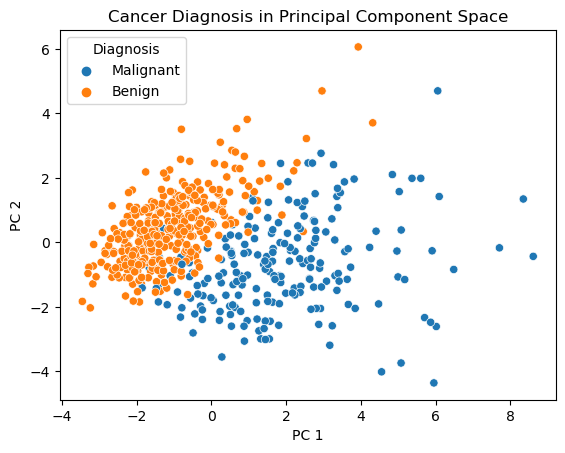

In [23]:
from sklearn.decomposition import PCA

# Scale complete data set
X = StandardScaler().fit_transform((cancer.drop('diagnosis', axis=1)))

# Project observations into principal component (PC) space
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X)

# Collect PC scores 
pca_scores_df = pd.DataFrame({
    'PC 1': pca_scores[:,0],
    'PC 2': pca_scores[:,1],
    'Diagnosis': ['Malignant' if d else 'Benign' for d in cancer.diagnosis]
})

# Plot PC scores
sns.scatterplot(data=pca_scores_df, x='PC 1', y='PC 2', hue='Diagnosis')
plt.title('Cancer Diagnosis in Principal Component Space');

In the plot above we see the cancer diagnoses in principal component space (i.e., the transformed observations - *scores*). It appears that the transformation is effective at separating the diagnoses. Specifically, we can see that the majority of the __benign__ samples are densely clustered and that the __malignant__ samples, while more dispersed, are mostly separated from the __benign__ samples. PCA has the additional benefit of enabling us to determine how much of the variance in the original data is explained by the transformed features (i.e., the contributions to variance of the principal components). In the table below we see that the first two principal components explain approx. 54% and 23% of the variance respectively, and that the cumulative contribution is approx. 76%.

In [24]:
# Variance explained
pd.DataFrame({
    'PC 1': round(pca.explained_variance_ratio_[0], 3),
    'PC 2': round(pca.explained_variance_ratio_[1], 3),
    'Cumulative': round(pca.explained_variance_ratio_.sum(), 3)
}, index=['Variance Explained'])

,PC 1,PC 2,Cumulative
Variance Explained,0.537,0.225,0.762


### Task 4.

Using a biplot we can see how the original features contribute to the principal components and additionally determine how the features are correlated. Inspecting the biplot below we can see that conavity and compactness are correlated (i.e., there is a small angle between the `compactness_mean`, `concavity_mean`, and `concave_points_mean` vectors) and have high contribution to PC 1. Additionally, we see that `fractal_dimension_mean` is likely uncorrelated with `texture_mean` and `area_mean` and these features contribute more stronly to PC 2 than any other features. Furthermore, `smoothness_mean` and `symmetry_mean` are extremely correlated and have an aproximately equal contribution to both PC 1 and PC 2. Finally, it appears that the general geometric characteristics of concavity, compactness, texture and area are strong indicators of a __malignant__ cancer sample.

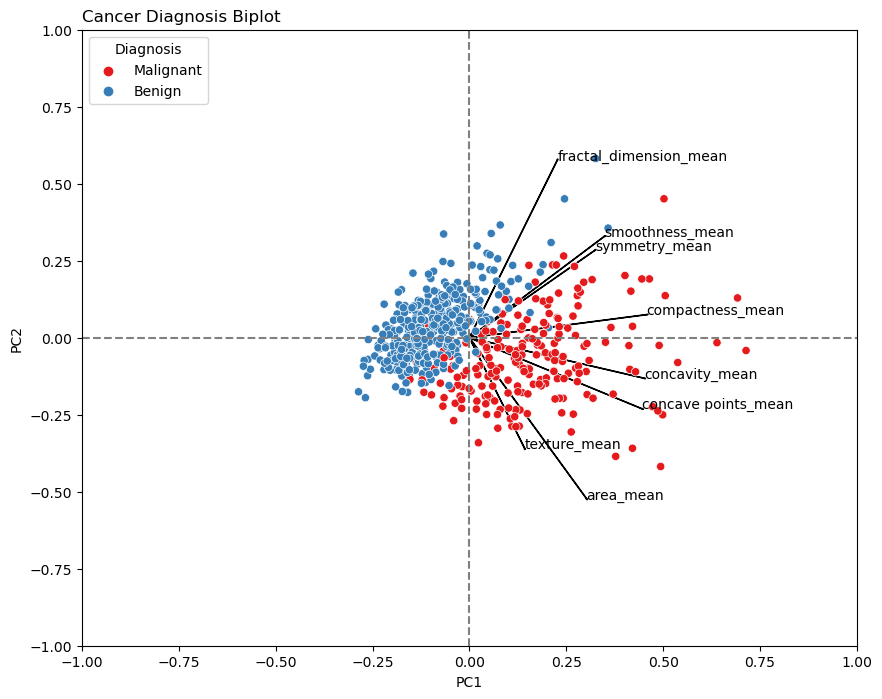

In [25]:
# Display principal components biplot
def display_biplot(PC1, PC2, loadings, features, groups, group_name, title, ticks=True):
    plt.xlim((-1,1))
    plt.ylim((-1,1))
    plt.plot([0,0],[-1,1],linestyle='dashed',color='grey')
    plt.plot([-1,1],[0,0],linestyle='dashed',color='grey')
    PC1_ = 1.0 / (PC1.max() - PC1.min())
    PC2_ = 1.0 / (PC2.max() - PC2.min())
    for i, feature in enumerate(features):
        plt.arrow(0,0,loadings[0,i],loadings[1,i])
        plt.text(loadings[0,i],loadings[1,i],feature)
    sns.scatterplot(x=PC1*PC1_,y=PC2*PC2_, hue=groups, palette='Set1')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    if not ticks:
        plt.xticks([])
        plt.yticks([])
    plt.legend(loc='upper left',title=group_name)
    plt.title(title,loc='left')

# Collect biplot data for display
PC1 = pca_scores[:,0]
PC2 = pca_scores[:,1]
loadings = pca.components_
features = cancer.columns[cancer.columns != 'diagnosis'] 
diagnosis = ['Malignant' if d else 'Benign' for d in cancer.diagnosis]

plt.figure(figsize=(10,8))
display_biplot(PC1, PC2, loadings, features, diagnosis, 'Diagnosis', 'Cancer Diagnosis Biplot')
plt.show()

### Task 5.

As outlined above, the magnitude, direction and angular separation of the loading vectors associated with the general geometric characteristics of __concavity__, __compactness__, and __texture__ and __area__, indicated a strong association with __malignant__ cancer samples. Importantly, recalling the conclusion from the analysis of feature importance in the logistic regression and decision tree models, we saw that __area__ and __concavity__ are very important characteristics for tumor classification, i.e., the size of the tumor and the irregularity of it's border. From these observations we can infer that both modelling techniques recognize similar feature characteristics in the classification of breast cancer samples.

### Task 6.

Continuing with PCA we can determine the number of components to retain 95% of the explained variance by calculating the cumulative contribution to total variance of each successive principal component. In the table below we see this total for the respective number of features and notice that 5 features are required to retain at least 95% of the variance (i.e., 5 features totals 97%).

In [26]:
pca = PCA()
pca_scores = pca.fit_transform(X)

# Cumulative variance of features
pd.DataFrame({
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_),
    '# Features': np.arange(1,9)
}).set_index('# Features')

,Cumulative Variance
# Features,
1,0.536679
2,0.762163
3,0.865153
4,0.927396
5,0.973887
6,0.986098
7,0.995770
8,1.000000


Now using the principal components that retain 95% of the variance we can transform the training and test data and fit the previous logistic regression model (`GridSearchCV-LogisticRegression`) to these newly transformed observations. With the new training and test data (i.e., dimensions $385 \times 5$ and $97 \times 5$ repsectively) we see in the results table below the relative performance metrics for the classifiers derived from the test data. Specifically, the model resulting from our PCA data (`GridSearchCV-LogisticRegression-PCA`) has superior performance over the decision tree model (`GridSearchCV-DecisionTree`) accross all metrics but the original logistic regression model retains highest performance among all three models.

In [27]:
# Retain predictions for later comparison
logreg_cv_preds = logreg_cv.predict(X_test)

# PCA on train, test data - 95% var. explained
pca = PCA(n_components=0.95)
pca.fit(X_train)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)

# Fit logistic regression model to PCA transormed train data
logreg_cv_pca = logreg_cv.fit(X_train_pca, y_train)

# Collect test data performance metrics
results = pd.DataFrame({
    'accuracy': [accuracy_score(y_test, logreg_cv_pca.predict(X_test_pca))],
    'precision': [precision_score(y_test, logreg_cv_pca.predict(X_test_pca))],
    'recall': [recall_score(y_test, logreg_cv_pca.predict(X_test_pca))],
    'f1': [f1_score(y_test, logreg_cv_pca.predict(X_test_pca))],
    'roc auc': [roc_auc_score(y_test, logreg_cv_pca.predict(X_test_pca))],
    'Classifier': ['GridSearchCV-LogisticRegression-PCA']
}).set_index('Classifier')

# Display results comparison
pd.concat([results_df, results])

,accuracy,precision,recall,f1,roc auc
Classifier,,,,,
GridSearchCV-LogisticRegression,0.948454,0.931034,0.900000,0.915254,0.935075
GridSearchCV-DecisionTree,0.917526,0.923077,0.800000,0.857143,0.885075
GridSearchCV-LogisticRegression-PCA,0.927835,0.925926,0.833333,0.877193,0.901741


To better understand the difference in classification performance between the orignal logistic regression model (`GridSearchCV-LogisticRegression`) and the current PCA model (`GridSearchCV-LogisticRegression-PCA`) we can investigate the particular classification errors resulting from the test data by displaying the confusion matrices.
We see in the confusion matrices below that the PCA model makes the same type of error as the decision tree model. Namely, the __True Positive__ classifications (approx. 26%) are lower than the original logistic regression model and this is accounted for by an increase in the number of __False Negative__ classifications (approx. 5%). As was outlined earlier, when considering the serious nature of cancer, there is much greater importance on preventing __False Negative__ diagnosis than in correctly identifying a __True Positive__ diagnosis and also in making a __False Positive__ error. With this in mind, and considering the increased complexity of the PCA modelling process, it is clear that the logistic regression model utilizing the full feature set of the original data is the preferred model.

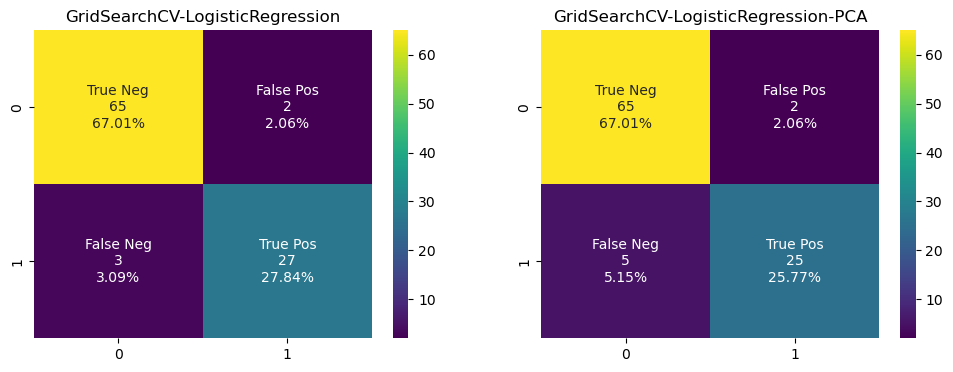

In [28]:
# Plot confusion matrices - test data
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
conf_mtx_1 = confusion_matrix(y_test, logreg_cv_preds, labels=logreg_cv.classes_)
display_conf_mtx(conf_mtx_1, title=classifier_names[0])
plt.subplot(1,2,2)
conf_mtx_2 = confusion_matrix(y_test, logreg_cv_pca.predict(X_test_pca), 
    labels=logreg_cv_pca.classes_)
display_conf_mtx(conf_mtx_2, title='GridSearchCV-LogisticRegression-PCA');

### Conclusions of Cancer Diagnosis Modelling

From the modelling procedures conducted on the breast cancer diagnostic data we are able to draw several conclusions:
- The logistic regression model attains the greatest average performance across all major metrics on the test data.
- The decision tree model and PCA logistic regression model both increase the likelihood of __False Negative__ errors above the standard logistic regression model.
- Certain general geometric characteristics of breast cancer samples are important in diagnostic classification (i.e., __area__; __concavity__; and __compactness__ are associated with *malignancy*) and account for a large proportion of variance in the sample data.

## A Clustering Analysis of Airline Safety Records

In this part of the notebook we aim to investigate airline safety records by performing clustering analysis. To uncover potential similarities or dissimilarities in such data we will look at safety records for major commercial airlines over a 30 year period. The [data](https://www.kaggle.com/datasets/fivethirtyeight/fivethirtyeight-airline-safety-dataset) contains information about the airline; available seats; incidents; accidents; and fatalities. Namely:

- __airline__ (asterisk indicates that regional subsidiaries are included)
- __avail seat km per week__: available seat kilometres flown every week. 
- __incidents 85 99__: total number of incidents, 1985-1999
- __fatal accidents 85 99__: total number of fatal accidents, 1985-1999
- __fatalities 85 99__: total number of fatalities, 1985-1999
- __incidents 00 14__: total number of incidents, 2000-2014
- __fatal accidents 00 14__: total number of fatal accidents, 2000-2014
- __fatalities 00 14__: total number of fatalities, 2000-2014

The clustering technique we shall utilize on these data is the k means algorithm. This technique partitions the data into distinct non-overlapping groups such that the within group similarity is high and the between group dissimilarity is high - similarity/dissimilarity is a measure of distance (e.g. *Euclidean*). This technique requires the pre-specificatin of the number of clusters, indicated by the variable k.

### Task 1.

Before employing clustering techniques we must perform a rudimentary inspection of the data in order to determine if preprocessing and/or transformation is required.

In [29]:
airline = pd.read_csv('airline-safety.csv')
airline.head()

,airline,avail_seat_km_per_week,incidents_85_99,fatal_accidents_85_99,fatalities_85_99,incidents_00_14,fatal_accidents_00_14,fatalities_00_14
0,Aer Lingus,320906734,2,0,0,0,0,0
1,Aeroflot*,1197672318,76,14,128,6,1,88
2,Aerolineas Argentinas,385803648,6,0,0,1,0,0
3,Aeromexico*,596871813,3,1,64,5,0,0
4,Air Canada,1865253802,2,0,0,2,0,0


The first thing to notice is that the data are segregated by time period, i.e., accidents, incidents, and fatalities fall into two separate periods: 1985-1999, and 2000-2014. Because we are aiming to investigate which airlines are *similar* based on their *past* safety records, it will be initially helpful to aggregate the the accidents, incidents, and fatalities across the time periods. In this way we may be able to determine how the airlines cluster with respect to their entire safety record. Additionally, the ariline name (i.e., text column) does not provide numeric information that will aid in clustering and can therefore be put aside. 

In [30]:
# Aggregate features over time periods
airline_totals = pd.DataFrame({
    'avail_seat_km_per_week': airline.avail_seat_km_per_week,
    'total_incidents': airline.incidents_85_99 + airline.incidents_00_14,
    'total_fatal_accidents': airline.fatal_accidents_85_99 + airline.fatal_accidents_00_14,
    'total_fatalities': airline.fatalities_85_99 + airline.fatalities_00_14
})

# Collect mean & standard deviation
mean_std = airline_totals.describe().loc[['mean', 'std'], :].transpose().sort_values(
        by='mean', ascending=False
    ).astype('int64')
mean_std

,mean,std
avail_seat_km_per_week,1384621304,1465316894
total_fatalities,167,188
total_incidents,11,13
total_fatal_accidents,2,3


The above table of means and standard deviations indicates that the scale varies significantly across the features.
Due to the k means algorithm being sensitive to the scale of features it is necessary that the data are scaled before performing the cluster analysis.

In [31]:
# Standardise airline features
std_scaler = StandardScaler()
X = std_scaler.fit_transform(airline_totals)

With the data appropriately scaled we are ready to partition the observations into clusters via the k-means algorithm using the Euclidean distance (i.e., Euclidean is the defualt distance metric). This rasies the question of how many clusters are suitable? There are several techniques utilised to assess or validate the evidence of the obtained clusters, but there has been no consensus on a single approach. With this in mind, we shall use the so called *silhouette score*, which is the mean silhouette coefficient over all instances where the silhouette coefficient ($SC$) of an instance $i$ is defined as:
$$SC_i = {(b - a) \over max(a, b)}$$
Where $a$ is the mean distance to other instances in the same cluster (i.e., the instance’s mean intra-cluster distance), and $b$ is the mean distance to the instances of the next closest cluster (i.e., the instance’s mean nearest-cluster distance, defined as the one that minimises b, excluding the instance’s own cluster). The objective is to maximize the *silhouette score* with respect to the number of clusters k, i.e., the best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar. Inspecting the plot below we can see that the *silhouette score* is maximal at k = 2 clusters.

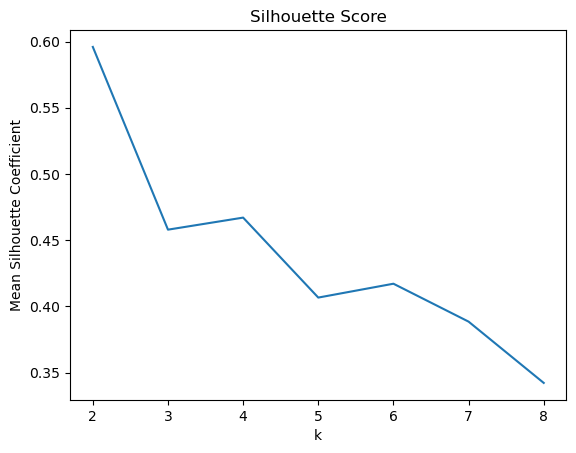

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Collect silhouette score for each k cluster arrangement
silhouette_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=5508)
    km.fit(X)
    silhouette_scores.append(silhouette_score(X, km.labels_))

# Plot silhouette score as function of k
pd.Series(silhouette_scores, index=range(2,9)).plot.line() 
plt.xlabel('k')
plt.ylabel('Mean Silhouette Coefficient')
plt.title('Silhouette Score');

### Task 2.

We now apply the k-means clustering algorithm to partition the aggregate airline safety data into our chosen k (i.e., k = 2) clusters. To visualise these assignments we plot the clusters for each feature pair of the dataset in a scatterplot below.

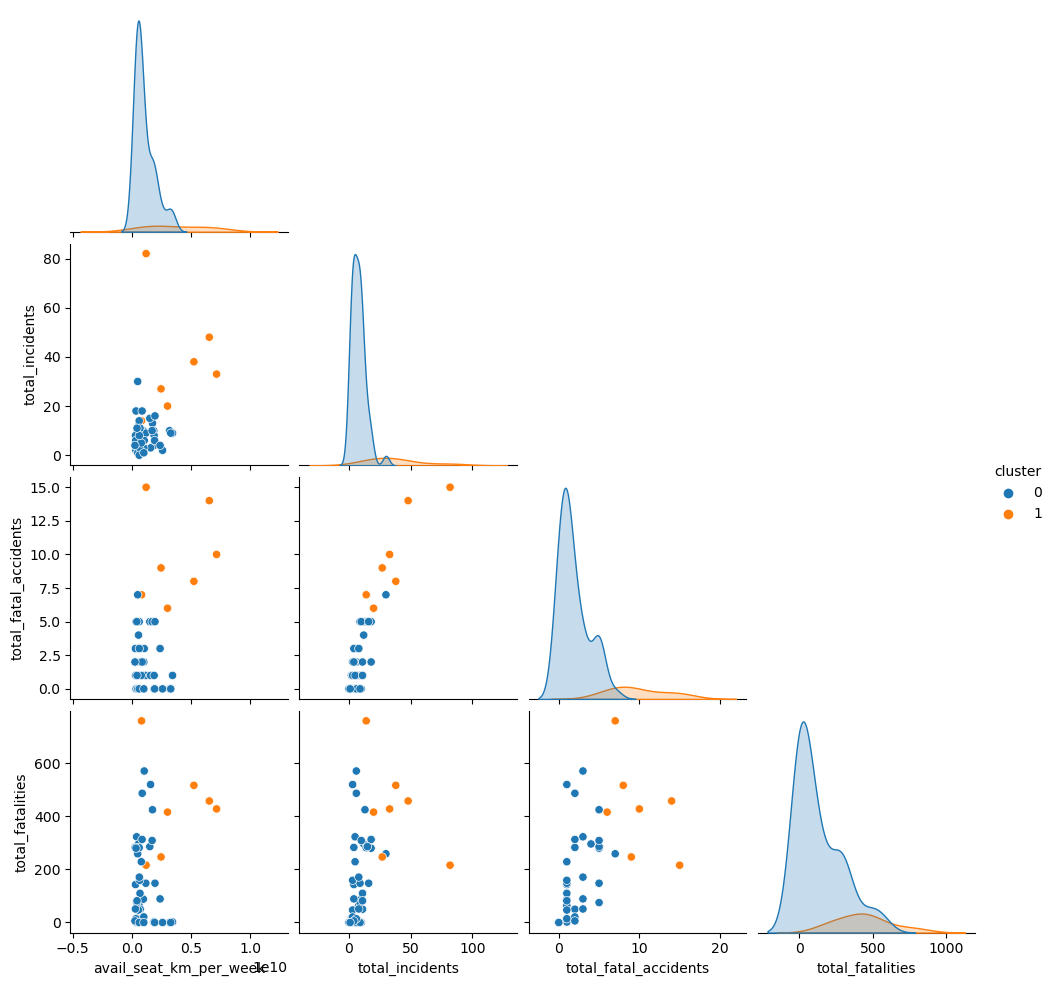

In [33]:
# Fit k = 2 clusters
km = KMeans(n_clusters=2, random_state=5508)
km.fit(X)

# Plot cluster assignments
airline_clusters = airline_totals.copy()
airline_clusters['cluster'] = km.labels_
sns.pairplot(data=airline_clusters, hue='cluster', corner=True);

The scatterplots above show that the density of cluster 0 data points is greatest in the lower left quadrant for each feature pair and that the upper right quadrant is devoid of any cluster 0 observations for all pairs. Additionally, cluster 1 observations appear to be more sparsely distributed within the scatterplots for each of the feature pairs. This indicates that the intercluster similarity of cluster 0 observations is greater that that of cluster 1, i.e., cluster 0 observations have more in common with one another than cluster 1 observations have with one another. To better understand the differences we can look directly the cluster assignments and characterise each feature by the mean within the respective cluster.

In [34]:
# Collect cluster means
means = airline_clusters.groupby('cluster').mean().astype('int64')
means

,avail_seat_km_per_week,total_incidents,total_fatal_accidents,total_fatalities
cluster,,,,
0,1044385840,7,1,129
1,3766269554,37,9,434


The above table of feature means for each cluster shows that the average value for each feature assigned to cluster 1 is much greater that that of feature 0. Indeed, if we look at the table of differences below, we see that the cluster 1 means are approx. 3.6 times greater for `available_seat_km_per_week`; 5.3 times greater for `total_incidents`; 9 times greater for `total_fatal_accidents`; and 3.4 times greater for `total_fatalities`. With respect to the aggregate airline safety data, if we consider incidents, accidents and fatalities together as a general characteristic indicating a poor (i.e., dangerous) safety record, then there appears to be a relationship between the available seat km of the airline and having a poor safety record. Specifically, airlines with higher available seat km's over time (1985-2014) tend to have an undesirable safety record when compared to airlines with much lower available seat km's per week.

In [35]:
# Difference in feature means of clusters
pd.DataFrame(means.iloc[1] / means.iloc[0], columns=['Cluster 1 / Cluster 0'])

,Cluster 1 / Cluster 0
avail_seat_km_per_week,3.606205
total_incidents,5.285714
total_fatal_accidents,9.000000
total_fatalities,3.364341


Here we will try to better understand which airlines in particular have both high levels of incidents and fatalities, and which of these airlines also have high available seat km's. To achieve this, we first determine the airlines that have highest fatalities and incidents by extracting the top quartiles of airlines with respect to `total_fatalities` and `total_incidents` and plot the airline and it's cluster assignment.

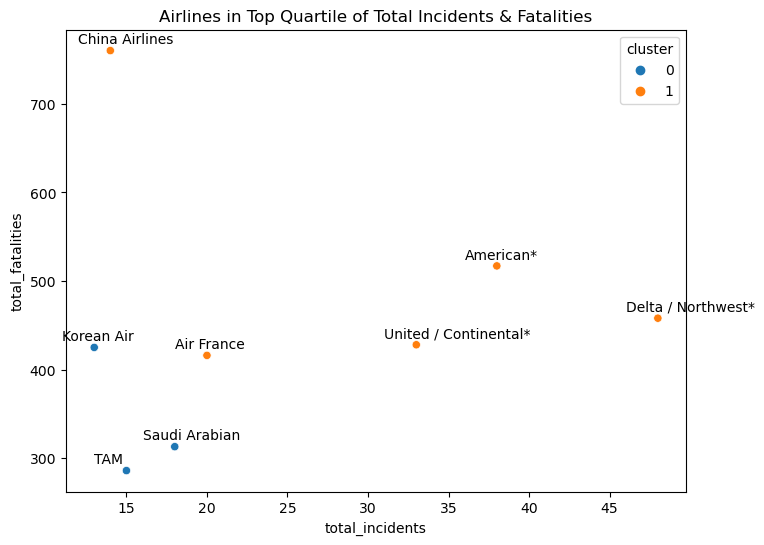

In [36]:
top_quartile = int(airline_clusters.shape[0] * 0.25)

# Top quartile of fatalities
fatalities = airline_clusters[['total_fatalities', 'cluster']].join(
    airline.airline
).sort_values(
    by='total_fatalities', ascending=False
).head(top_quartile)

# Top quartile of incidents
incidents = airline_clusters[['total_incidents', 'cluster']].join(
    airline.airline
).sort_values(
    by='total_incidents', ascending=False
).head(top_quartile)

# Airlines common to both top quartile of fatalities & incidents
bad_airlines = fatalities.merge(incidents, how='inner')

# Plot results
plt.figure(figsize=(8,6))
p = sns.scatterplot(
    data=bad_airlines,
    x='total_incidents',
    y='total_fatalities',
    hue='cluster'
)
for i, name in enumerate(bad_airlines.airline):
    p.text(
        bad_airlines.total_incidents[i]-2,
        bad_airlines.total_fatalities[i]+8,
        name
    )
plt.title('Airlines in Top Quartile of Total Incidents & Fatalities')
plt.show()

From the scatterplot above we can see that over 60% of the airlines with poor safety metrics are assigned to cluster 1. Additionally, the large American airlines (i.e., __American__, __Delta/Northwest__ and __United/Continental__) and their subsidiaries account for a high proportion of the airlines with poorest safety records and that they are also assigned to cluster 1. Furthermore, __China Arilines__ appears to be different to the other cluster 1 airlines in that it has a relatively low number of incidents but a very high number of fatalities. Finally, inspecting the table below, we see all the airlines that are common to both those in the highest quartile of `total_fatalities`, `total_incidents` and `avail_seat_km_per_week`. From the table it appears that 75% of the airlines with the highest available seat km's and worst safety records over time are American and that they are all assigned to cluster 1. These observations potentially indicate a difference in the operating characteristics of large Amercian airlines that appears to have detrimental effects on safety metrics.

In [37]:
# Top quartile of available seat km's per week
seat_km = airline_clusters[['avail_seat_km_per_week', 'cluster']].join(
    airline.airline
).sort_values(
    by='avail_seat_km_per_week', ascending=False
).head(top_quartile)

# Airlines common to both top quartile of fatalities, incidents & available seat km's
bad_airlines.merge(seat_km, how='inner')

,total_fatalities,cluster,airline,total_incidents,avail_seat_km_per_week
0,517,1,American*,38,5228357340
1,458,1,Delta / Northwest*,48,6525658894
2,428,1,United / Continental*,33,7139291291
3,416,1,Air France,20,3004002661


### Task 3.

The approach taken in k-means clustering is to partition the data into clusters by associating each cluster (and the resulting assignments to these clusters) with it's *center of mass*. Specifically, observations are clustered together if they a similar to one another. This similarity is measured by the *distance* that observations are from the cluster center, i.e., the *center of mass*. Because the similarity/dissimilarity is defined by distance, it is important that the features are on comparable scales, hence the requirement for scaling the data prior to clustering. Given this requirement, it is clear then that the data must be numeric in order to perfrom cluster analysis, hence text features such as airline names are not required for the cluster assignment but can be utilised in the proceeding analysis. Finally, with the goal being to uncover common characteristics among airline safety records over time, it was appropriate to aggregate the data over the time periods (i.e., 1985-2014) before performing the cluster analysis.

### Task 4.

We would now like to consider if (and how) the cluster arrangements change over time. To do this we shall determine the cluster assignments of the airline safety records for the two time periods separately (i.e., 1985-1999 and 2000-2014). We will use the same k (k = 2) identified earlier.

In [38]:
# Separate the time periods
airline_85_99 = airline[['incidents_85_99', 'fatal_accidents_85_99', 'fatalities_85_99']]
airline_00_14 = airline[['incidents_00_14', 'fatal_accidents_00_14', 'fatalities_00_14']]

# Extract cluster assignments for each time period
for time_period in [airline_85_99, airline_00_14]:
    std_scaler = StandardScaler()
    X = std_scaler.fit_transform(time_period)
    km = KMeans(n_clusters=2, random_state=5508)
    km.fit(X)
    time_period['cluster'] = km.labels_

# Collect and display results
clusters_over_time = pd.DataFrame({
    'Airline': airline.airline,
    '1985-1999 Clusters': airline_85_99.cluster,
    '2000-2014 Clusters': airline_00_14.cluster,
    'Cluster Change': airline_85_99.cluster != airline_00_14.cluster,
    #'1985-2014 Clusters': airline_clusters.cluster,
})

clusters_over_time.head(20)

,Airline,1985-1999 Clusters,2000-2014 Clusters,Cluster Change
0,Aer Lingus,0,1,True
1,Aeroflot*,1,0,True
2,Aerolineas Argentinas,0,1,True
3,Aeromexico*,0,1,True
4,Air Canada,0,1,True
5,Air France,0,0,False
6,Air India*,0,0,False
7,Air New Zealand*,0,1,True
8,Alaska Airlines*,0,0,False
9,Alitalia,0,1,True


In the table above we see that a number of cluster assignments for each of the respective airlines have changed over time. To determine precisely how many airlines have been assigned different clusters for the different time periods we can display the distribution with a pie chart (see below).

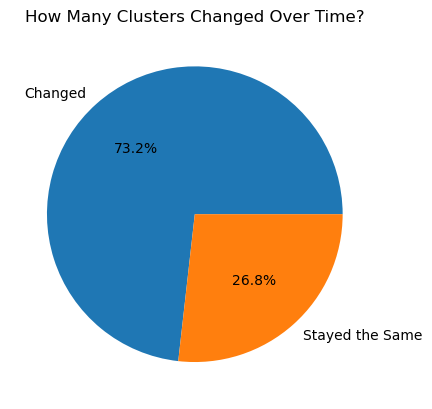

In [39]:
# Frequency of cluster changes over time
counts = clusters_over_time['Cluster Change'].value_counts()
counts = counts / counts.sum()
plt.pie(counts, labels=['Changed', 'Stayed the Same'], autopct='%1.1f%%')
plt.title('How Many Clusters Changed Over Time?')
plt.show();

It is clear from the pie chart that the overwhelming number (approx. 73%) of airlines changed in cluster assignment in the 2000-2014 time period from their previous assignment during the 1985-1999 time period whilst only approx. 27% of the airlines were stable in the respective cluster assignments across the time periods. This evokes the question of why the cluster arrangements changed? We may be able to answer this question by analysing how the safety records changed over the time periods. Inspecting the table below we see that the mean number of incidents, fatal accidents and fatalities has *declined* over time. In particular, __incidents__ have declined by __57%__, __fatal accidents__ by __30%__ and __fatalities__ by __49%__. From this analysis, we may conclude that the 73% change in cluster assignment among the airlines is likely due to an average improvement in safety over the time periods from 1985-1999 to 2000-2014 and the k-means algorithm is recognizing this change in the safety metrics and subsequently partioning the airlines into cluster arrangements based on this. 

In [40]:
# Means of safety records for each time period
airline_85_99.drop('cluster', axis=1, inplace=True)
airline_00_14.drop('cluster', axis=1, inplace=True)
means_85_99 = airline_85_99.mean().reset_index(drop=True)
means_00_14 = airline_00_14.mean().reset_index(drop=True)

# Percentage change in means over time periods
pct_change = means_00_14 / means_85_99 
pct_change *= 100.
pct_change = pct_change.round(0)

# Collect and display results
pd.DataFrame({
    '1985-1999': means_85_99,
    '2000-2014': means_00_14,
    'Percentage Decline': pct_change,
    'Safety Metric': ['Incidents', 'Fatal Accidents', 'Fatalities']
}).set_index('Safety Metric')

,1985-1999,2000-2014,Percentage Decline
Safety Metric,,,
Incidents,7.178571,4.125000,57.0
Fatal Accidents,2.178571,0.660714,30.0
Fatalities,112.410714,55.517857,49.0


### Task 5.

We shall now consider three new features as the ratio of the variables from 2000-2014 divided by the respec- tive variables from 1985-1999 (i.e., `incidents_ratio`, `fatal_accidents_ratio`, `fatalities_ratio`) and perform k-means cluster analysis with the previously identified number of clusters (i.e., k = 2). In the table below we see that values greater than 1 indicate and increase in the safety metric over the time periods whilst values less than 1 indicate a decline in the safety metric.

In [41]:
# Compute ratio: 2000-2014 / 1985-1999
airline_ratios = airline_00_14.divide(airline_85_99.values).replace(
    [np.inf, np.nan], 0
)
airline_ratios.columns = ['incidents_ratio', 'fatal_accidents_ratio', 'fatalities_ratio'] 
airline_ratios.head()

,incidents_ratio,fatal_accidents_ratio,fatalities_ratio
0,0.000000,0.000000,0.0000
1,0.078947,0.071429,0.6875
2,0.166667,0.000000,0.0000
3,1.666667,0.000000,0.0000
4,1.000000,0.000000,0.0000


In order to determine the similarities and differences of the clustering results of the ratio data with those cluster arrangements in the previous analyses we require a relative basis on which to perform the comparison. For this we can reduce the dimensions of the data by projecting the cluster assignemnts of the safety record observations into principal component space. First we collect the principal component transformations and cluster assignments for each of the time periods (i.e., `all-time`, `1985-1999`, `2000-2014`, `2000-2014 / 1985-1999`).

In [42]:
pca_data = dict() 
names = ['all_time', '85-99', '00-14', 'ratio']
airline_data = [airline_totals, airline_85_99, airline_00_14, airline_ratios]

# Collect PCA & cluster data
for name, air in zip(names, airline_data):
    std_scaler = StandardScaler()
    X = std_scaler.fit_transform(air)
    km = KMeans(n_clusters=2, random_state=5508)
    km.fit(X)
    pca = PCA()
    pca.fit(X)
    pca_scores = pca.fit_transform(X)
    PC1 = pca_scores[:,0]
    PC2 = pca_scores[:,1]
    loadings = pca.components_
    features = air.columns
    clusters = km.labels_
    pca_data[name] = (PC1, PC2, loadings, features, clusters)


Now we display the resulting cluster arrangements in the first two dimensions of principal component space (i.e., PC1, PC2) with the associated loading vectors.

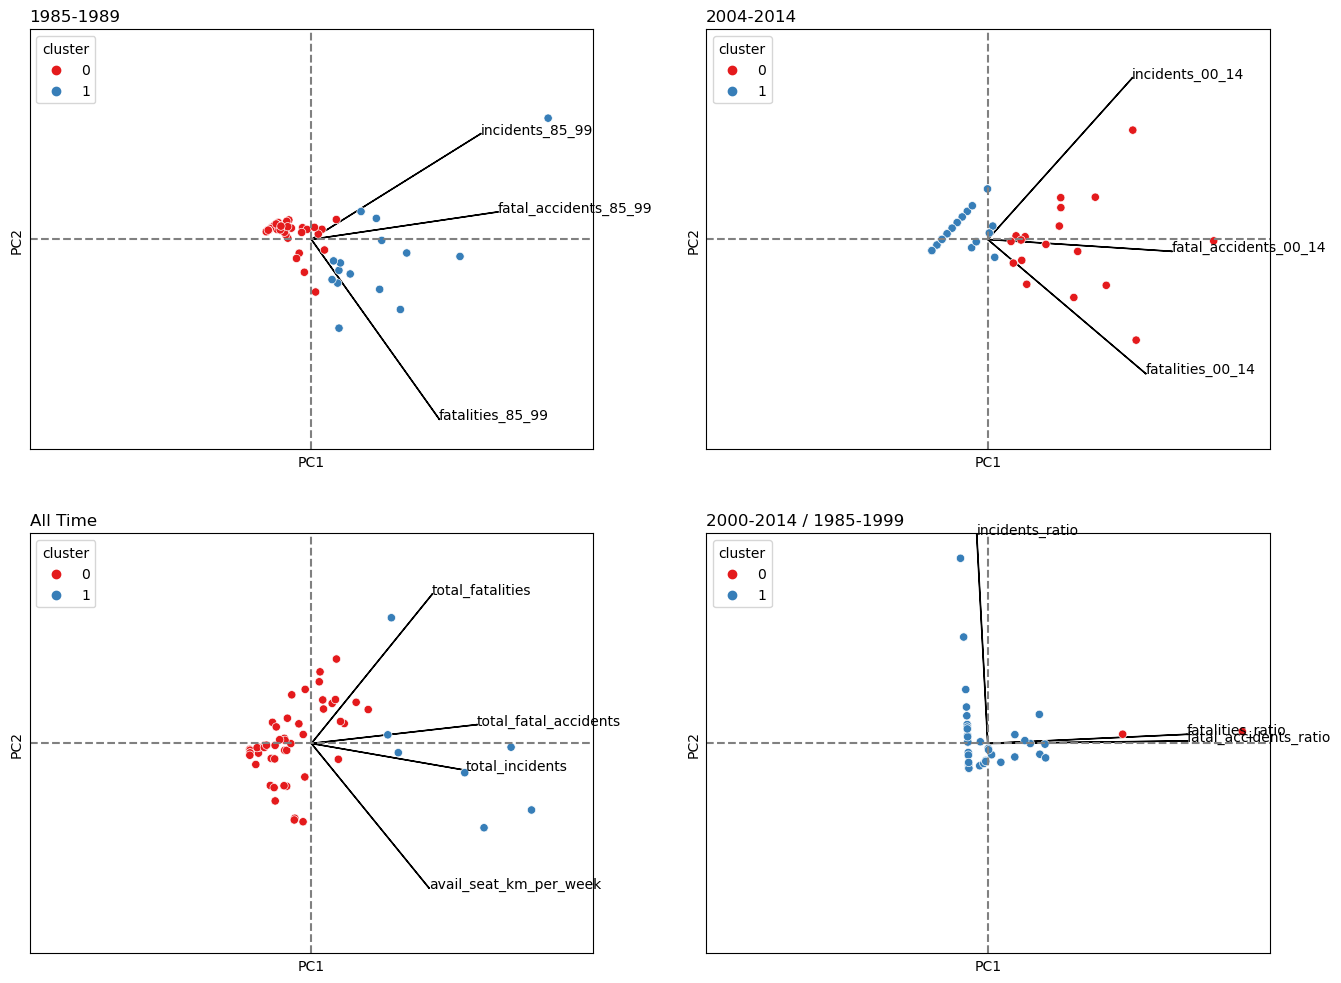

In [43]:
# Display biplots and cluster assignments
plt.figure(figsize=(16,12))
plt.subplot(2,2,1)
display_biplot(
    PC1=pca_data['85-99'][0],
    PC2=pca_data['85-99'][1],
    loadings=pca_data['85-99'][2],
    features=pca_data['85-99'][3],
    groups=pca_data['85-99'][4],
    group_name='cluster',
    title='1985-1989',
    ticks=False
)
plt.subplot(2,2,2)
display_biplot(
    PC1=pca_data['00-14'][0],
    PC2=pca_data['00-14'][1],
    loadings=pca_data['00-14'][2],
    features=pca_data['00-14'][3],
    groups=pca_data['00-14'][4],
    group_name='cluster',
    title='2004-2014',
    ticks=False
)
plt.subplot(2,2,3)
display_biplot(
    PC1=pca_data['all_time'][0],
    PC2=pca_data['all_time'][1],
    loadings=pca_data['all_time'][2],
    features=pca_data['all_time'][3],
    groups=pca_data['all_time'][4],
    group_name='cluster',
    title='All Time',
    ticks=False
)
plt.subplot(2,2,4)
display_biplot(
    PC1=pca_data['ratio'][0],
    PC2=pca_data['ratio'][1],
    loadings=pca_data['ratio'][2],
    features=pca_data['ratio'][3],
    groups=pca_data['ratio'][4],
    group_name='cluster',
    title='2000-2014 / 1985-1999',
    ticks=False
)
plt.show();

By analysing the above biplots we can see the result of the 75% change in cluster assignments from 1989-1999 to 2000-2014 which was identified earlier. Specifically, the loading vectors for incidents, accidents and fatalities are arranged similarly but the cluster 1 assignments change from being within the angle between the incidents and fatalities vectors in 1989-1999 period to being oustside the respective angle in the 2000-2014 period. Again, as discovered earlier, this is likely driven by the corresponding decline in average safety metrics. 

Turning now to the aggregate metrics across all time, we see that total incidents and fatal accidents drive the variation in the first principal component and that the k-means cluster assignments are stronly influenced by these metrics. Recalling also that the large American airlines were responsible for a large proportion of total fatalities and total incidents but that China arilines was an outlier in this respect (i.e., large number of total fatalities but total incidents were comparitively low). 

Finally, we examine the ratio of the time periods (i.e., 2000-2014 / 1989-1999). We notice first that cluster 1 accounts for the majority of the ratios and is densely populated around the center of the PC1, PC2 space; that the fatalities and fatal accidents ratios are almost perfectly correlated and drive the majority of variation in the ratios; the incidents ratio is not correlated with the fatalities and fatal accidents ratios; and that the small proportion of cluster 1 ratios are positioned far along the PC1 axis. Because the ratios indicate a change in the corresponding safety metrics for each particular airline over the time periods we can infer that the majority of airlines safety records did not change by a large amount but a small number of airlines safety records changed by an inordinate amount.

### Conclusions of  Clustering Analysis on Airlines Safety Records

From the clustering analysis conducted on the airline safety records data we are able to draw several conclusions:
- When the data are aggregated across the time periods from 1989-1999 and 2000-2014 we see a large difference in the cluster means of all safety metrics (i.e., available seat km per week; total incidents; total fatal accidents; and total fatalities).
- The large American airlines (i.e., American; Delta/Northwest; and United/Continental) and subsidiaries account for a large proportion of the airlines with the worst safety records over the aggregate time period.
- A majority (approx. 75%) of the cluster assignments change over the time periods from 1989-1999 to 2000-2014 and the corresponding safety metrics improve on average (i.e., there is a *decline* in the number of incidents, fatal accidents and fatalities).
- The cluster assignments for the ratio of the safety metrics across time periods (i.e., 2000-2014 / 1989-1999) indicate that the majority of airlines safety metrics changed by small amounts but a small number of airlines had proportionally large changes in both fatal accidents and fatalities, and incidents.

## A Clustering Analysis of US Arrests Data 

In this part of the notebook we shall investigate crime rates by performing clustering analysis of arrests in the United States of America. The __USArrests__ data contains the statistics, in arrests per 100,000 residents, for three crime-related features (__assault__, __murder__ and __rape__) for all 50 US states in 1973. An additional feature, __UrbanPop__, is also included and describes the percentage of the population living in urban areas.

This data contains 50 observations on 4 variables, namley:
- __Murder__: murder arrests (per 100,000)
- __Assault__: assault arrests (per 100,000)
- __Rape__: rape arrests (per 100,000)
- __UrbanPop__: percent of the population living in urban areas

For this analysis we shall utilise the agglomerative clustering approach. This technique hierarchically divides the observations into distinct clusters that form an inverted tree known as a *dendrogram*. Using a bottom-up approach the algorithm starts with individual data points and iteratively merges them into a smaller number of clusters (i.e., starting with *n* clusters that contain a single observation and successively merging clusters until all observations are contained within a single cluster at the root of the dendrogram). In contrast to the k-means approach, agglomerative clustering does not require the pre-specification for the number of clusters.

### Task 1.

Using the raw data we shall perform a hierarchical clustering with *complete* linkage using the *Euclidean* distance to cluster the states. 

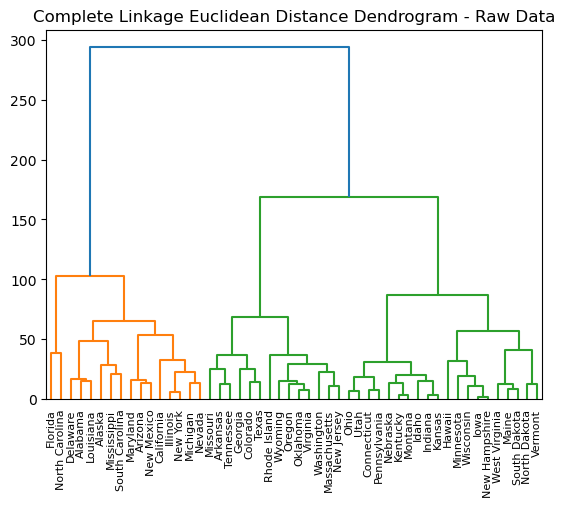

In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Load and format data
arrests = pd.read_csv('USArrests.csv')
X = arrests.set_index('State')

# Plot cluster dendrogram - # clusters unspecified
dn = dendrogram(
    linkage(X, 'complete', 'euclidean'),
    labels=X.index
);
plt.title('Complete Linkage Euclidean Distance Dendrogram - Raw Data')
plt.show()

From the dendrogram above we can see that three distinct cluster form at a an approximate height of 150. Now we shall cut the dendrogram at a height that results in three clusters and determine how the states are partitioned and what the respective characteristics are.

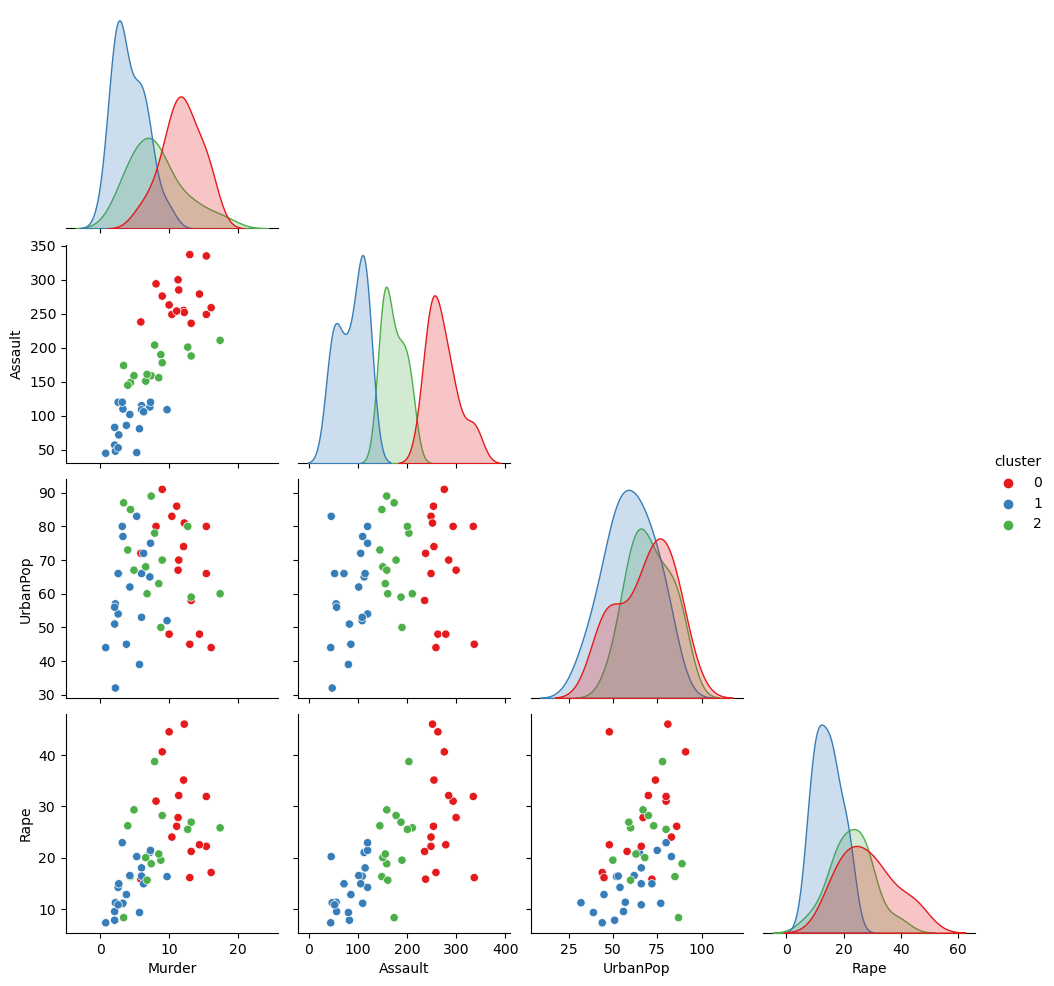

In [45]:
from sklearn.cluster import AgglomerativeClustering

# Partition states into 3 distinct clusters
clusters = AgglomerativeClustering(n_clusters=3, linkage='complete')
clusters.fit(X)

# Collect and display cluster assignments
arrests_clusters = arrests.copy()
arrests_clusters['cluster'] = clusters.labels_
sns.pairplot(
    data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')],
    hue='cluster',
    corner=True,
    palette='Set1'
);

The scatterplots above indiate a mixture of visually intuitive separation between cluster (i.e., murder and assault) among more diffuse cluster assignemnts (i.e., difficult to identify separate clusters in UrbanPop and murder). Let us investigate the distributional characteristics more precisely with boxplots. 

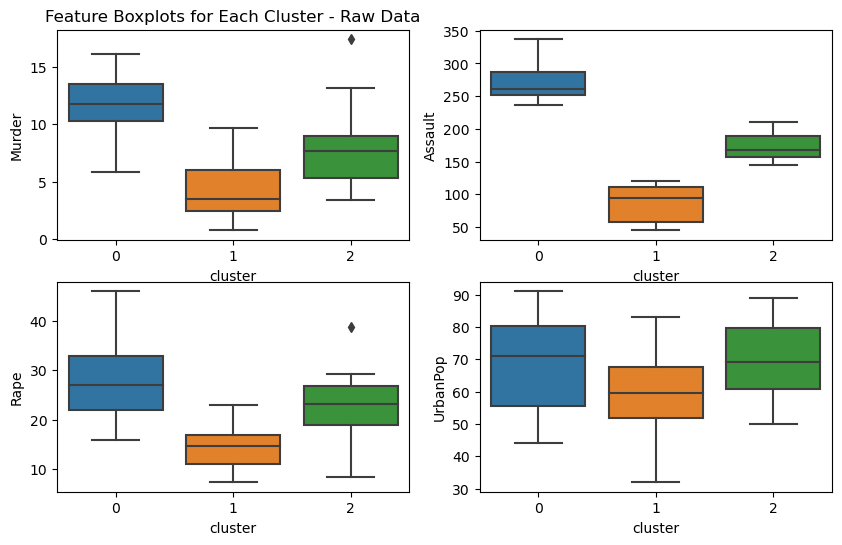

In [46]:
# Feature boxplots for each cluster
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Murder')
plt.title('Feature Boxplots for Each Cluster - Raw Data');
plt.subplot(2,2,2)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Assault')
plt.subplot(2,2,3)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Rape')
plt.subplot(2,2,4)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='UrbanPop');
plt.show()

Inspecting the above boxplots for each feature it is apparent that the overall *"safest"* states are within cluster 1, i.e., the median is lowest for all features in cluster 1 and in terms of __assault__ rates, all values in the distribution of cluster 1 are lower than the bottom of the entire first quartile of both other clusters. Similar patterns are present for __murder__ and __rape__. Let us see which states fall into the respective categories of crime (i.e., `Lowest Crime Rates`; `Medial Crime Rates`; `Highest Crime Rates`) that result from the clustering.

In [47]:
# Collect and display low; medial; high crime states
crime_states = pd.DataFrame({
    'Lowest Crime Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 1, :].State.reset_index(drop=True),
    'Medial Crime Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 2, :].State.reset_index(drop=True),
    'Highest Crime Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 0, :].State.reset_index(drop=True),
})
crime_states

,Lowest Crime Rates,Medial Crime Rates,Highest Crime Rates
0,Connecticut,Arkansas,Alabama
1,Hawaii,Colorado,Alaska
2,Idaho,Georgia,Arizona
3,Indiana,Massachusetts,California
4,Iowa,Missouri,Delaware
5,Kansas,New Jersey,Florida
6,Kentucky,Oklahoma,Illinois
7,Maine,Oregon,Louisiana
8,Minnesota,Rhode Island,Maryland
9,Montana,Tennessee,Michigan


The table above does not immediately indicate any particular geographic charactersitc common to each of the respective crime rates, i.e., the states are widely dispersed across the country for each respective rate of crime. For example, New York and Alaska are high in crime whilst Hawaii and both North and South Dakota are low in crime - these regions are drastically different from one another but are clustered in the same crime categories. Let us now determine if the average population density is associated with the respective crime rates. In the table below we see that the lowest population density does indeed correspond to the lowess crime rate but the mean population densities of the medial and highest crimes do not differ significantly.

In [48]:
# Compute and display mean population and corresponding crime rate
crime_pop = arrests_clusters.groupby('cluster').mean().loc[:, ['UrbanPop']]
crime_pop['Crime Rate'] = ['Highest', 'Lowest', 'Medial']
crime_pop.columns = ['Mean Urban Population', 'Crime Rate']
crime_pop.sort_values('Mean Urban Population', ascending=False)

,Mean Urban Population,Crime Rate
cluster,,
2,70.642857,Medial
0,68.312500,Highest
1,59.750000,Lowest


### Task 2.

The preceeding anlysis used the raw (i.e., unscaled) data and this likely affected he results. We shall now perform the analysis again with scaled data to determine if there are differences in the resulting clusters and which method is more appropriate for these data. We begin as before by partitioning the scaled data into 3 distinct clusters and inspecting the results with visualizations and statistics.

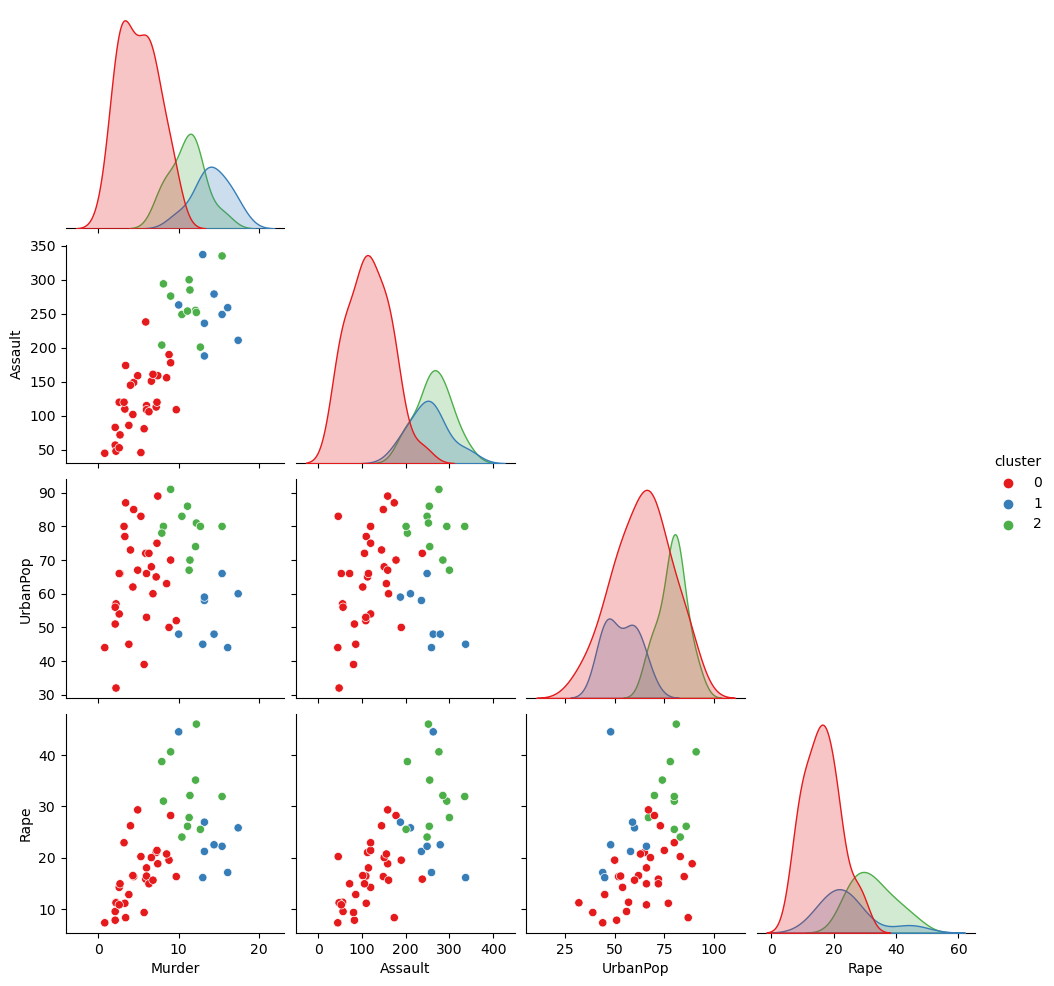

In [49]:
# Retain raw data clusters
raw_clusters = arrests_clusters.cluster

# Scale the data
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

# Partition states into 3 distinct clusters
clusters = AgglomerativeClustering(n_clusters=3, linkage='complete')
clusters.fit(X_std)

# Collect and display cluster assignments
arrests_clusters = arrests.copy()
arrests_clusters['cluster'] = clusters.labels_
sns.pairplot(
    data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')],
    hue='cluster',
    corner=True,
    palette='Set1'
);

From the above scatterplots we can see an immediate distributional difference in the cluster arrangements for the scaled data from the raw data. Specifically, the observations from the same clusters are much more clearly separated from othe clusters, particularly for cluster 0 (i.e., the red points). Additionally, there is clearly a greater number of observations in cluster 0 than the other two clusters, as is indicated by the much larger mean and concentration of the density estimates (i.e., the red curves). Let us now look at which states in particular are clustered together and what the respective crime rates are. To determine this we will again utilise box plots.

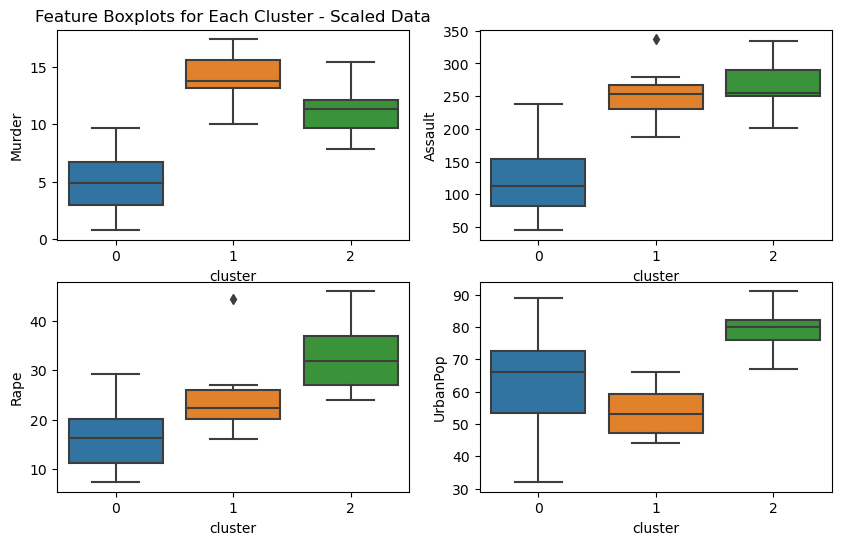

In [50]:
# Feature boxplots for each cluster
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Murder')
plt.title('Feature Boxplots for Each Cluster - Scaled Data');
plt.subplot(2,2,2)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Assault')
plt.subplot(2,2,3)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Rape')
plt.subplot(2,2,4)
sns.boxplot(data=arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='UrbanPop');
plt.show()

The boxplots above indicate that the lowest overall crime rates occur in states within cluster 0 and that cluster 2 has higher crime rates than cluster 1 for __assault__ and __rape__ but lower rates of __murder__. Furthermore, the differences in spread and interquartile ranges of cluster 1 and 2 make it difficult to clearly differentiate the overall rates of crime within these clusters. For this reason it is appropriate to classify cluster 2 as having overall *highest* __rape__ and __assault__, whilst cluster 1 has *highest* __murder__.

In [51]:
# Retain raw crime states
crime_states_raw = crime_states

# Collect and display low; medial; high crime states
crime_states = pd.DataFrame({
    'Lowest Crime Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 0, :].State.reset_index(drop=True),
    'Highest Murder Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 1, :].State.reset_index(drop=True),
    'Highest Rape & Assault Rates': 
        arrests_clusters.loc[arrests_clusters['cluster'] == 2, :].State.reset_index(drop=True),
})
crime_states

,Lowest Crime Rates,Highest Murder Rates,Highest Rape & Assault Rates
0,Arkansas,Alabama,Arizona
1,Connecticut,Alaska,California
2,Delaware,Georgia,Colorado
3,Hawaii,Louisiana,Florida
4,Idaho,Mississippi,Illinois
5,Indiana,North Carolina,Maryland
6,Iowa,South Carolina,Michigan
7,Kansas,Tennessee,Nevada
8,Kentucky,NaN,New Mexico
9,Maine,NaN,New York


From the table above we can immediately see that the scaled cluster assignemnts are quite different to the unscaled. Specifically, lowest crime rate state account for the great majority of the cluster distributions and highest murder rate states account for a proportionally small amount of the cluster distributions. Let us now determine which states have the *worst* crime rates across both cluster partions (i.e., the states that are common to the highest crime rates in the unscaled data and to the highest murder rates as well as the highest assualt and rape rates).

In [52]:
# Collect and display worst crime states - both scaled & raw data
murder_idx = crime_states_raw['Highest Crime Rates'].isin(
    crime_states['Highest Murder Rates'].dropna()
)
rape_assault_idx = crime_states_raw['Highest Crime Rates'].isin(
    crime_states['Highest Rape & Assault Rates'].dropna()
)
worst_crime_states = crime_states_raw.loc[murder_idx, 'Highest Crime Rates'].append(
    crime_states_raw.loc[rape_assault_idx, 'Highest Crime Rates'],ignore_index=True
).to_frame(name='Worst Crime States')
worst_crime_states

,Worst Crime States
0,Alabama
1,Alaska
2,Louisiana
3,Mississippi
4,North Carolina
5,South Carolina
6,Arizona
7,California
8,Florida
9,Illinois


From the table above we can see that some of the worst crime states are among the largest in terms of population in America (e.g., California and New York) whilst others are comparitively less populated (e.g., Alaska). To better understand the distributional differences in urban population between those sates with the worst crime rates and those with the lowest we will collect and compare those statistics against the complete distribution of urban population (i.e., all states).

In [53]:
# Worst crime states urban population statistics
worst_urbanPop = arrests.loc[arrests['State'].isin(
    worst_crime_states.squeeze()
), 'UrbanPop'].describe().to_frame(name='Worst Crime States Urban Population')

# All states urban population statistics
all_urbanPop = arrests['UrbanPop'].describe().to_frame(name='All States Urban Population')

# Lowest crime states urban population statistics
lowest_urbanPop = arrests.loc[arrests['State'].isin(
    crime_states['Lowest Crime Rates'].squeeze()
), 'UrbanPop'].describe().to_frame(name='Lowest Crime States Urban Population')

pd.concat([all_urbanPop, worst_urbanPop, lowest_urbanPop], axis=1)

,All States Urban Population,Worst Crime States Urban Population,Lowest Crime States Urban Population
count,50.000000,15.000000,31.000000
mean,65.540000,68.066667,63.838710
std,14.474763,16.002083,14.210552
min,32.000000,44.000000,32.000000
25%,54.500000,53.000000,53.500000
50%,66.000000,70.000000,66.000000
75%,77.750000,80.500000,72.500000
max,91.000000,91.000000,89.000000


The table of statictics above shows that the distributions of urban population in the lowest crime rate states does not differ significantly from the complete distribution of all states. On the other hand, the urban population of the worst crime states does differ from both that of the lowest crime and all states (i.e., the mean, median, and standard deviation are all greater in the states with worst crime rates). To visualize these differences we shall plot the associated kernel density estimates.

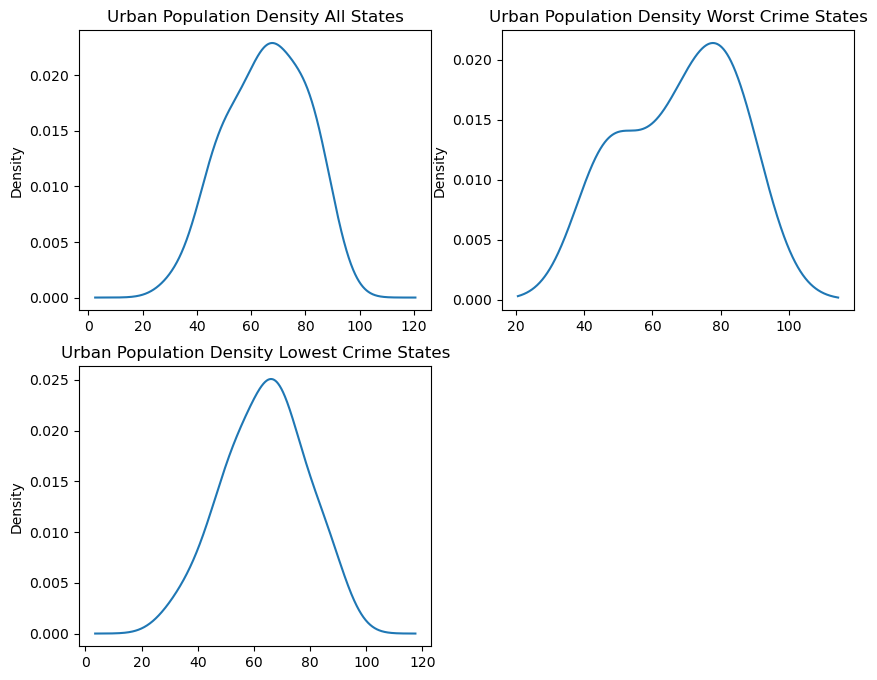

In [54]:
# Urban population density estimates - all/worst crime states 
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
arrests['UrbanPop'].plot(kind='density')
plt.title('Urban Population Density All States')
plt.subplot(2,2,2)
arrests.loc[arrests['State'].isin(worst_crime_states.squeeze()), 'UrbanPop'].plot(kind='density')
plt.title('Urban Population Density Worst Crime States')
plt.subplot(2,2,3)
arrests.loc[arrests['State'].isin(crime_states['Lowest Crime Rates'].squeeze()), 'UrbanPop'].plot(kind='density')
plt.title('Urban Population Density Lowest Crime States')
plt.show();

Inspecting the density estimates above we can see that the urban population density of the worst crime states does indeed differ from the others. Specifically, the spread is much greater and there is a small degree of bimodality present. With these observations and the results from the preceeding analysis in mind, it is appropriate that the arrests data are scaled for agglomerative clustering.

### Task 3.

We shall now perform principal component analysis on the data before hierarchical clustering with complete linkage and Euclidean distance on the first two principal component score vectors rather than the raw data.

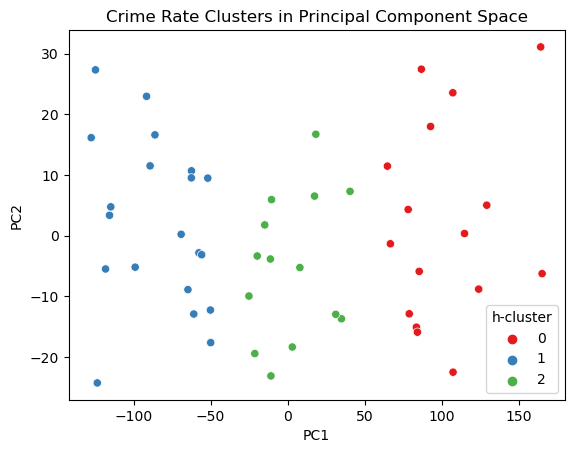

In [55]:
# PCA transform arrests data
pca = PCA()
pca.fit(X_std)
pca_scores = pca.fit_transform(X)

# Partition PC1, PC2 scores into 3 clusters
clusters = AgglomerativeClustering(n_clusters=3, linkage='complete')
clusters.fit(pca_scores[:,0:2])

# Collect results and plot cluster assignments
pca_arrests_clusters = pd.concat(
    [arrests, pd.Series(clusters.labels_, name='cluster')], axis=1
)
pca_data = pd.DataFrame({
    'PC1': pca_scores[:,0],
    'PC2': pca_scores[:,1],
    'h-cluster': clusters.labels_ 
})
sns.scatterplot(data=pca_data, x='PC1', y='PC2', hue='h-cluster', palette='Set1')
plt.title('Crime Rate Clusters in Principal Component Space')
plt.show()

The scatterplot above shows cluster assignments are quite well separated along the PC1 axis, but are not well separated along the PC2 axis (i.e., at approx. PC1 = -50, PC1 = 50, clusters 1, 2, and 0 are respectively separated). Let us know investigate the distributional characteristics of the cluster assignments to determine the categorizations of the respective crime rate states (i.e., low, medial, and high crime rates). For this we can again utilize boxplots.

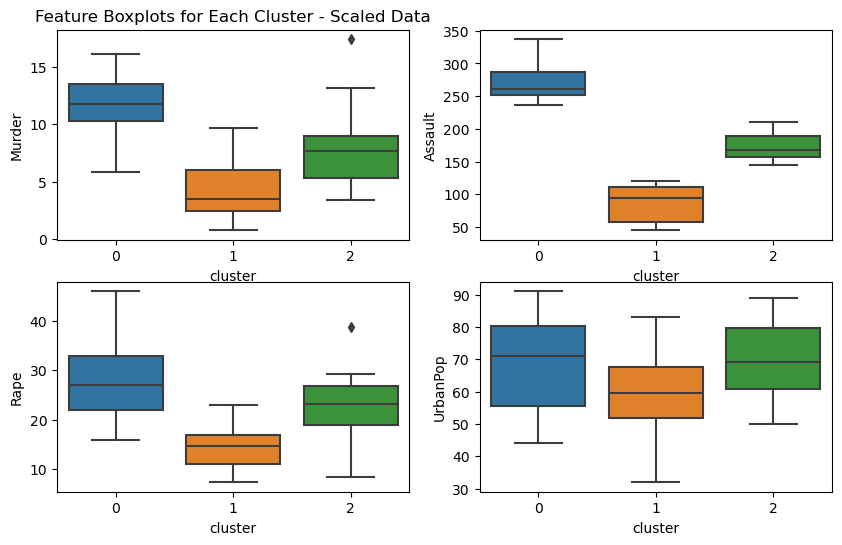

In [56]:
# Feature boxplots for each cluster - PCA
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.boxplot(data=pca_arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Murder')
plt.title('Feature Boxplots for Each Cluster - Scaled Data');
plt.subplot(2,2,2)
sns.boxplot(data=pca_arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Assault')
plt.subplot(2,2,3)
sns.boxplot(data=pca_arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='Rape')
plt.subplot(2,2,4)
sns.boxplot(data=pca_arrests_clusters.loc[:, (arrests_clusters.columns != 'State')], x='cluster', y='UrbanPop');
plt.show()

From the above boxplots we see that cluster 0 has the highest crime rates for murder, assualt and rape in addition to the highest population density. Cluster 1 has the lowest rates among all the arrest types whilst cluster 2 has medial cime rates among the three clusters. Let us now determine the specific states that fall into these categories and compare them with the respective categories for the scaled data from the previous analysis.

In [57]:
# Collect and display low; medial; high crime states
pca_crime_states = pd.DataFrame({
    'Lowest Crime Rates (PCA)': 
        pca_arrests_clusters.loc[pca_arrests_clusters['cluster'] == 1, :].State.reset_index(drop=True),
    'Medial Crime Rates (PCA)': 
        pca_arrests_clusters.loc[pca_arrests_clusters['cluster'] == 2, :].State.reset_index(drop=True),
    'Highest Crime Rates (PCA)': 
        pca_arrests_clusters.loc[pca_arrests_clusters['cluster'] == 0, :].State.reset_index(drop=True),
})
pd.concat([crime_states, pca_crime_states], axis=1)

,Lowest Crime Rates,Highest Murder Rates,Highest Rape & Assault Rates,Lowest Crime Rates (PCA),Medial Crime Rates (PCA),Highest Crime Rates (PCA)
0,Arkansas,Alabama,Arizona,Connecticut,Arkansas,Alabama
1,Connecticut,Alaska,California,Hawaii,Colorado,Alaska
2,Delaware,Georgia,Colorado,Idaho,Georgia,Arizona
3,Hawaii,Louisiana,Florida,Indiana,Massachusetts,California
4,Idaho,Mississippi,Illinois,Iowa,Missouri,Delaware
5,Indiana,North Carolina,Maryland,Kansas,New Jersey,Florida
6,Iowa,South Carolina,Michigan,Kentucky,Oklahoma,Illinois
7,Kansas,Tennessee,Nevada,Maine,Oregon,Louisiana
8,Kentucky,NaN,New Mexico,Minnesota,Rhode Island,Maryland
9,Maine,NaN,New York,Montana,Tennessee,Michigan


It is immediately obvious from the above table that the distrubtions among the cluster categories is more balanced than in the PCA case than for the scaled data. Furthermore, it appears that the clustering of the PCA transformed data has appropriately combined the high rates of both murder, and rape and assault into the single cluster associated with the highest overall crime rates. To further investigate this we shall compare the previously determined *worst* crime states with the highest crime rates of the PCA analysis.

In [58]:
# Collect worst crime states with highest PCA crime states
pd.concat(
    [worst_crime_states.sort_values('Worst Crime States').reset_index(drop=True),
    pca_crime_states[['Highest Crime Rates (PCA)']].sort_values('Highest Crime Rates (PCA)').reset_index(drop=True)],
    axis=1
)

,Worst Crime States,Highest Crime Rates (PCA)
0,Alabama,Alabama
1,Alaska,Alaska
2,Arizona,Arizona
3,California,California
4,Florida,Delaware
5,Illinois,Florida
6,Louisiana,Illinois
7,Maryland,Louisiana
8,Michigan,Maryland
9,Mississippi,Michigan


From the table above we see that the clustering assingments of the PCA transformed data have identified all the worst cime states that we investigated previously as those with the highest crime rates in addition to another state - Delaware.

### Task 4.

Now we shall use the k-means clustering approach to partition the PCA transformed data, i.e., we will use the first two principal components score vectors as *features* and set the initial centroids of the k-means as the group means obtained from the hierarchical clustering. Specifically, the cluster centroids must ["be of shape (n_clusters, n_features) and gives the initial centers."](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). Hence the centroid data we require is presented in the table below.

In [59]:
# Cluster centroids - hierarchical clusters (PCA)
centroids = pca_data.groupby('h-cluster').mean()
centroids

,PC1,PC2
h-cluster,,
0,102.149155,2.020236
1,-83.741577,1.982213
2,2.888932,-5.140574


With the centroids we now initialise the k-means algorithm and fit the PCA data after which we plot the resulting cluster assignments in principal component space and compare those with the hierarchical clusters.

In [64]:
# Initialise & fit k-means
km = KMeans(
    n_clusters=3, 
    init=centroids.to_numpy(),
    #n_init=1, DOESN'T MATTER
    random_state=5508
)
km.fit(pca_scores[:,0:2])

# Collect k-means cluster assignemnts
pca_data['km-cluster'] = km.labels_

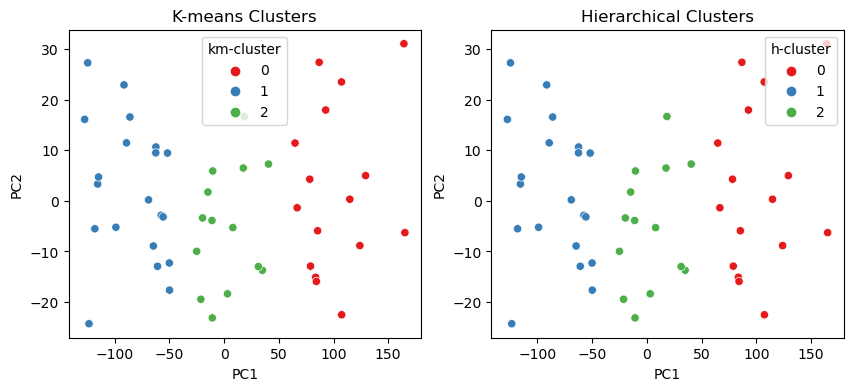

In [65]:
# Plot k-means & hierarchical clusters in PC1, PC2 space
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(data=pca_data, x='PC1', y='PC2', hue='km-cluster', palette='Set1')
plt.title('K-means Clusters')
plt.subplot(1,2,2)
sns.scatterplot(data=pca_data, x='PC1', y='PC2', hue='h-cluster', palette='Set1')
plt.title('Hierarchical Clusters')
plt.show()

Interestingly, we can see in the scatter plots above that both the k-means and hierarchical methods have partitioned the the first two principal component scores data (PC1, PC2) into identical clusters. Generally, these methods produce different cluster arrangements. But if we consider that the cluster centroids used to initialise the k-means algorithm were the cluster means produced from the hierarchical clusters, then it is entirely plausible that both methods would determine the same cluster arrangements. Given these observations, and the fact that the k-means approach requires the pre-specification of the number of clusters, the preference over which method is appropriated depends both on the data and the desired outcome of the analysis. If we know the number of clusters the data need be partitioned into, then the k-means approach is preferable. Alternatively, if the number of clusters is unknown or the data do not naturally contain specific groups, then the hierarchical approach is preferable.

### Conclusions of Clustering Analysis on US Arrests Data

From this clustering analysis of US arrests data several conclusions can be drawn:
- Urban population density of states is weakly correlated with crime rates but high crime states have slight distributional differences with low crime rate states. 
- The hierarchical approach with scaled data appears to identify geniune clusters in the data that correspond to states with low crime rates; high murder rates; and high assault and rape rates.
- The hierarchical approach with principal component data identifies an additional high crime state - Delaware.
- Whe using the centroids from the hierarchical clusters of the first two principal component scores data, the k-means method identifies identical cluster assignments to the hierarchical method.